## Importações

## Imports

In [191]:
import warnings
warnings.filterwarnings("ignore")

In [192]:
import math
import os
import time
import requests
import pandas as pd
import json
import numpy as np
from pathlib import Path
from typing import Optional, Dict, List, Union
from unidecode import unidecode
import matplotlib.pyplot as plt

import pandas_gbq
from google.auth import default
from google.cloud import bigquery
from google.api_core.exceptions import NotFound

from IPython.display import display

In [193]:
from funcoes_escoragem import *

In [194]:
BASE_DIR = Path("data")
RAW_DIR = BASE_DIR / "raw"
TRUSTED_DIR = BASE_DIR / "trusted"
ANALYTICS_DIR = BASE_DIR / "analytics"

for path in [RAW_DIR, TRUSTED_DIR, ANALYTICS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

## Funções

In [195]:
PF_COL = "tipo"
TARGET_COLS = ["pc_2m", "pc_3m", "pcc_2m", "pcc_3m", "pd_2m", "pd_3m"]
TARGET_LABELS = {
    "pc_2m": "PC competência 2m",
    "pc_3m": "PC competência 3m",
    "pcc_2m": "PC caixa 2m",
    "pcc_3m": "PC caixa 3m",
    "pd_2m": "PD 2m",
    "pd_3m": "PD 3m",
}

# Faixas fixas de prazo (solicitação → ativação)
SLA_BINS = [0, 1, 3, 7, 15, np.inf]
SLA_LABELS = ["0", "1-2", "3-6", "7-14", ">=15"]


def format_metric_value(v):
    """Formata percentuais e contagens."""
    if isinstance(v, (float, np.floating)) and float(v) <= 1:
        return f"{float(v):.1%}".replace(".", ",")
    return f"{int(v):,}".replace(",", ".")


def filter_pf_activated(df: pd.DataFrame, pf_col: str = PF_COL) -> pd.DataFrame:
    """Retorna contratos PF com data de ativação preenchida."""
    out = df[(df[pf_col] == "PF") & df["activated_at"].notna()].copy()
    out["requested_at"] = pd.to_datetime(out["requested_at"], errors="coerce")
    out["activated_at"] = pd.to_datetime(out["activated_at"], errors="coerce")
    out["safra_ativacao"] = pd.to_datetime(out["safra_ativacao"], errors="coerce")
    return out


def add_days_req_to_act(df: pd.DataFrame) -> pd.DataFrame:
    """Adiciona dias entre solicitação e ativação."""
    out = df.copy()
    out["dias_req_ativ"] = (out["activated_at"] - out["requested_at"]).dt.days
    return out


def add_sla_bin(
    df: pd.DataFrame,
    bins=None,
    labels=None,
    col: str = "dias_req_ativ",
) -> pd.DataFrame:
    """Cria faixas de prazo (intervalos semiabertos à direita)."""
    bins = SLA_BINS if bins is None else bins
    labels = SLA_LABELS if labels is None else labels
    out = df.copy()
    out["faixa_prazo"] = pd.cut(
        out[col].clip(lower=0),
        bins=bins,
        labels=labels,
        right=False,
        include_lowest=True,
    )
    return out


def initial_pf_activation_rates(df: pd.DataFrame, pf_col: str = PF_COL) -> pd.DataFrame:
    """Percentuais iniciais na base de contratos ativados."""
    is_pf = df[pf_col] == "PF"
    n_pf = int(is_pf.sum())
    n_uni = int((is_pf & (df["is_multiproponente"] == 0)).sum())
    n_multi = int((is_pf & (df["is_multiproponente"] == 1)).sum())
    return pd.DataFrame(
        {
            "métrica": [
                "% PF",
                "% uniproponente entre PF",
                "% multiproponente entre PF",
                "qtd total (ativados)",
                "qtd PF",
                "qtd uniproponente",
                "qtd multiproponente",
            ],
            "valor": [
                is_pf.mean(),
                (n_uni / n_pf) if n_pf else np.nan,
                (n_multi / n_pf) if n_pf else np.nan,
                len(df),
                n_pf,
                n_uni,
                n_multi,
            ],
        }
    )


def build_funnel_table(df: pd.DataFrame, pf_col: str = PF_COL) -> pd.DataFrame:
    """Monta o funil para base só de ativados: Total → PF → Uni / Multi."""
    n_total = len(df)
    is_pf = df[pf_col] == "PF"
    n_pf = int(is_pf.sum())
    n_uni = int((is_pf & (df["is_multiproponente"] == 0)).sum())
    n_multi = int((is_pf & (df["is_multiproponente"] == 1)).sum())

    funnel = pd.DataFrame(
        {
            "etapa": ["Total", "PF", "Uniproponente", "Multiproponente"],
            "qtd": [n_total, n_pf, n_uni, n_multi],
        }
    )
    funnel["pct_total"] = funnel["qtd"] / n_total
    funnel["pct_anterior"] = funnel["qtd"] / funnel["qtd"].shift(1)
    funnel.loc[0, "pct_anterior"] = 1.0
    # Uni/Multi são participação dentro de PF (não conversão sequencial)
    funnel.loc[funnel["etapa"].isin(["Uniproponente", "Multiproponente"]), "pct_anterior"] = (
        funnel.loc[funnel["etapa"].isin(["Uniproponente", "Multiproponente"]), "qtd"] / n_pf
        if n_pf
        else np.nan
    )
    return funnel.rename(
        columns={
            "pct_total": "% do total",
            "pct_anterior": "% da etapa anterior",
        }
    )


def plot_funnel(funnel: pd.DataFrame) -> None:
    """Plota Total → PF e a divisão Uni/Multi entre os PF."""
    n_pf = int(funnel.loc[funnel["etapa"] == "PF", "qtd"].iloc[0])
    stages_main = funnel.iloc[:2].copy()
    split = funnel.iloc[2:].copy()
    pct_total_col = "% do total"

    fig, axes = plt.subplots(2, 1, figsize=(10, 7.5))

    ax = axes[0]
    y = np.arange(len(stages_main))[::-1]
    ax.barh(y, stages_main["qtd"], color=["#4C72B0", "#55A868"], height=0.55)
    ax.set_yticks(y)
    ax.set_yticklabels(stages_main["etapa"])
    ax.set_xlabel("Contratos")
    ax.set_title("Funil: Total (ativados) → PF", pad=14)
    xmax = float(stages_main["qtd"].max()) * 1.35
    ax.set_xlim(0, xmax)
    for i, (n, pct) in enumerate(zip(stages_main["qtd"], stages_main[pct_total_col])):
        ax.text(
            n + xmax * 0.015,
            y[i],
            f"{n:,.0f} ({pct:.1%})".replace(",", "X").replace(".", ",").replace("X", "."),
            va="center",
            ha="left",
            fontsize=10,
        )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax = axes[1]
    x = np.arange(len(split))
    values = split["qtd"].to_numpy(dtype=float)
    ax.bar(x, values, color=["#8172B2", "#CCB974"], width=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(["Uniproponente", "Multiproponente"])
    ax.set_ylabel("Contratos")
    ax.set_title("PF: uniproponente vs multiproponente", pad=14)
    ymax = float(values.max()) * 1.28 if len(values) else 1.0
    ax.set_ylim(0, ymax)
    for i, n in enumerate(values):
        pct = (n / n_pf) if n_pf else 0.0
        texto = f"{n:,.0f}\n({pct:.1%})".replace(",", "X").replace(".", ",").replace("X", ".")
        ax.text(i, n + ymax * 0.04, texto, ha="center", va="bottom", fontsize=10, linespacing=1.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    fig.subplots_adjust(left=0.12, right=0.96, top=0.94, bottom=0.08, hspace=0.45)
    plt.show()


def sla_bin_volume(df: pd.DataFrame, col: str = "faixa_prazo") -> pd.DataFrame:
    """Volumetria por faixa de prazo."""
    return (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
        .rename_axis("faixa_prazo")
        .to_frame("qtd")
        .assign(**{"%": lambda x: x["qtd"] / x["qtd"].sum()})
    )


def cohort_perf(df: pd.DataFrame, target: str, cohort: str = "safra_ativacao") -> pd.DataFrame:
    """Performance por safra para um indicador binário já presente na base."""
    g = df.groupby(cohort)[target]
    out = pd.DataFrame(
        {
            "qtd_ativados": df.groupby(cohort).size(),
            "qtd_maturados": g.apply(lambda s: s.notna().sum()),
            "qtd_maus": g.sum(min_count=1),
            "taxa": g.mean(),
        }
    )
    out["cobertura_maturidade"] = out["qtd_maturados"] / out["qtd_ativados"]
    out.index.name = "safra_ativacao"
    return out


def plot_cohort_rates(perf: pd.DataFrame, title: str, rate_col: str = "taxa") -> None:
    """Gráfico de taxa e volumetria maturada por safra."""
    fig, ax1 = plt.subplots(figsize=(12, 4.8))
    x = perf.index.astype(str)
    ax1.plot(x, perf[rate_col], marker="o", color="#C44E52", label="taxa")
    ax1.set_ylabel("Taxa")
    ax1.set_xlabel("Safra de ativação")
    ax1.tick_params(axis="x", rotation=45)

    ax2 = ax1.twinx()
    ax2.bar(x, perf["qtd_maturados"], alpha=0.25, color="#4C72B0", label="qtd maturados")
    ax2.set_ylabel("Volumetria maturada")

    ax1.set_title(title, pad=12)
    fig.subplots_adjust(left=0.08, right=0.92, top=0.88, bottom=0.22)
    plt.show()


def summarize_targets(df: pd.DataFrame, targets=None) -> pd.DataFrame:
    """Resumo de volumetria maturada e taxa por indicador."""
    targets = TARGET_COLS if targets is None else targets
    rows = []
    for t in targets:
        s = df[t]
        n_maturado = int(s.notna().sum())
        rows.append(
            {
                "indicador": TARGET_LABELS.get(t, t),
                "qtd_ativados": len(df),
                "qtd_maturados": n_maturado,
                "cobertura_maturidade": n_maturado / len(df) if len(df) else np.nan,
                "taxa": s.mean(),
            }
        )
    return pd.DataFrame(rows)


# Mapeamento modeloBlend + bureau_nm -> modelo (Blend2/3/4/Outros)
# Fonte: planilha de classificacao do nome do modelo
BLEND_MODEL_MAP = pd.DataFrame(
    [
        {"modeloBlend": "", "bureau_nm": "BLEND_REGRESSAO", "modelo": "Blend2"},
        {"modeloBlend": "", "bureau_nm": "BLEND_REGRESSAO_OTIMISTA", "modelo": "Blend2"},
        {"modeloBlend": "BLEND_REGRESSAO", "bureau_nm": "BLEND_REGRESSAO", "modelo": "Blend2"},
        {"modeloBlend": "BLEND_REGRESSAO_2026", "bureau_nm": "BLEND_REGRESSAO_2026", "modelo": "Blend2"},
        {"modeloBlend": "", "bureau_nm": "BVS_CUSTOM", "modelo": "Blend2"},
        {"modeloBlend": "", "bureau_nm": "HVA3", "modelo": "Blend2"},
        {"modeloBlend": "BLEND_REGRESSAO", "bureau_nm": "BVS_CUSTOM", "modelo": "Blend2"},
        {"modeloBlend": "BLEND_REGRESSAO", "bureau_nm": "HVA3", "modelo": "Blend2"},
        {"modeloBlend": "BLEND_REGRESSAO_2026", "bureau_nm": "BVS_CUSTOM", "modelo": "Blend2"},
        {"modeloBlend": "BLEND_REGRESSAO_2026", "bureau_nm": "HVA3", "modelo": "Blend2"},
        {"modeloBlend": "", "bureau_nm": "BVS_CUSTOM_OTIMISTA", "modelo": "Blend2"},
        {"modeloBlend": "BLEND3_2", "bureau_nm": "BLEND3_2", "modelo": "Blend3"},
        {"modeloBlend": "BLEND3_3", "bureau_nm": "BLEND3_3", "modelo": "Blend3"},
        {"modeloBlend": "BLEND3_4", "bureau_nm": "BLEND3_4", "modelo": "Blend3"},
        {"modeloBlend": "BLEND3_2", "bureau_nm": "HVA4", "modelo": "Blend3"},
        {"modeloBlend": "BLEND3_3", "bureau_nm": "BVS_CUSTOM", "modelo": "Blend3"},
        {"modeloBlend": "BLEND3_3", "bureau_nm": "HVA4", "modelo": "Blend3"},
        {"modeloBlend": "BLEND_4", "bureau_nm": "BLEND_4", "modelo": "Blend4"},
        {"modeloBlend": "BLEND_4", "bureau_nm": "BLEND3_3", "modelo": "Blend4"},
        {"modeloBlend": "BLEND_4", "bureau_nm": "BVS_CUSTOM_V2", "modelo": "Blend4"},
        {"modeloBlend": "BLEND_4", "bureau_nm": "HFT1", "modelo": "Blend4"},
        {"modeloBlend": "BVS_CUSTOM_V2", "bureau_nm": "BVS_CUSTOM_V2", "modelo": "Blend4"},
        {"modeloBlend": "HFT1", "bureau_nm": "HFT1", "modelo": "Blend4"},
        {"modeloBlend": "", "bureau_nm": "", "modelo": "Outros"},
        {"modeloBlend": "", "bureau_nm": "BLEND_HVA3_BVS", "modelo": "Outros"},
        {"modeloBlend": "", "bureau_nm": "BVS", "modelo": "Outros"},
        {"modeloBlend": "", "bureau_nm": "HVAR", "modelo": "Outros"},
        {"modeloBlend": "BLEND3_BVS", "bureau_nm": "BLEND3_BVS", "modelo": "Outros"},
        {"modeloBlend": "BLEND3_BVS", "bureau_nm": "BVS_CUSTOM", "modelo": "Outros"},
        {"modeloBlend": "BLEND3_BVS", "bureau_nm": "HVA4", "modelo": "Outros"},
        {"modeloBlend": "BLEND3_POD", "bureau_nm": "BLEND3_POD", "modelo": "Outros"},
        {"modeloBlend": "BLEND3_POD", "bureau_nm": "HVA4", "modelo": "Outros"},
    ]
)

BLEND_MODELS = ["Blend2", "Blend3", "Blend4"]
# Modelos usados nos plots de volumetria/inadimplência (fallback=0, só uniproponente)
BLEND_MODELS_PLOT = [
    "Blend2",
    "Blend3",
    # "Blend4",
]


def _normalize_blend_key(series: pd.Series) -> pd.Series:
    """Normaliza chaves de junção (nulo/NaN -> string vazia)."""
    return (
        series.astype("string")
        .fillna("")
        .str.strip()
        .replace({"<NA>": "", "nan": "", "None": "", "NaN": ""})
    )


# Regra SQL de is_fallback (construida em Python)
FALLBACK_BUREAUS = ["BVS_CUSTOM_V2", "HFT1", "BVS_CUSTOM", "HVA4"]


def add_is_fallback(
    df: pd.DataFrame,
    modelo_col: str = "modeloBlend",
    bureau_col: str = "bureau_nm",
) -> pd.DataFrame:
    """
    Cria is_fallback com a regra SQL:
    1 se modeloBlend ou bureau_nm em (BVS_CUSTOM_V2, HFT1, BVS_CUSTOM, HVA4); senao 0.
    """
    out = df.copy()
    mb = _normalize_blend_key(out[modelo_col])
    bu = _normalize_blend_key(out[bureau_col])
    out["is_fallback"] = (
        mb.isin(FALLBACK_BUREAUS) | bu.isin(FALLBACK_BUREAUS)
    ).astype(int)
    return out


def add_blend_model_columns(
    df: pd.DataFrame,
    modelo_col: str = "modeloBlend",
    bureau_col: str = "bureau_nm",
) -> pd.DataFrame:
    """
    Cria:
    - modelo: Blend2/Blend3/Blend4/Outros (mapa da planilha)
    - is_fallback: regra SQL em Python
    """
    out = add_is_fallback(df, modelo_col=modelo_col, bureau_col=bureau_col)
    left = pd.DataFrame(
        {
            "_modelo_key": _normalize_blend_key(out[modelo_col]),
            "_bureau_key": _normalize_blend_key(out[bureau_col]),
        },
        index=out.index,
    )
    right = BLEND_MODEL_MAP.copy()
    right["_modelo_key"] = _normalize_blend_key(right["modeloBlend"])
    right["_bureau_key"] = _normalize_blend_key(right["bureau_nm"])
    # Usa so a coluna modelo do mapa; is_fallback vem da regra SQL
    right = right[["_modelo_key", "_bureau_key", "modelo"]].drop_duplicates()

    merged = left.merge(right, on=["_modelo_key", "_bureau_key"], how="left")
    out["modelo"] = merged["modelo"].fillna("Outros").values
    return out


def blend_volume_table(df: pd.DataFrame) -> pd.DataFrame:
    """Volumetria por modelo, is_fallback e uniproponente/multiproponente."""
    tmp = df.copy()
    tmp["segmento"] = np.where(tmp["is_multiproponente"] == 1, "Multiproponente", "Uniproponente")
    out = (
        tmp.groupby(["modelo", "is_fallback", "segmento"], dropna=False)
        .size()
        .rename("qtd")
        .reset_index()
    )
    out["%"] = out["qtd"] / len(tmp) if len(tmp) else np.nan
    return out.sort_values(["modelo", "is_fallback", "segmento"])


## Base Contratos Ativados

In [196]:
df_sim_ctr = pd.read_parquet(f"{BASE_DIR}/base_ctr_performance.parquet")
df_sim_ctr = df_sim_ctr[df_sim_ctr["safra_ativacao"] >= pd.to_datetime("2024-01-01")]
df_sim_ctr

,contract_id,dt_lead,requested_at,iniciada_at,enviada_at,activated_at,cancelled_at,dt_saida,safra,safra_ativacao,...,pd_2m,pd_3m,pd_6m,pd_9m,pd_12m,pcc_2m,pcc_3m,pcc_6m,pcc_9m,pcc_12m
1,1494718,2024-01-02,2024-01-02,NaT,2024-01-02,2024-01-05,2025-11-26,2025-11-19,2024-01-01,2024-01-01,...,0,0,0,0,0,0,0,0,0,0
2,1494591,2024-01-02,2024-01-02,NaT,2024-01-02,2024-01-03,NaT,2025-09-30,2024-01-01,2024-01-01,...,0,0,1,1,1,1,1,1,1,1
3,1495076,2024-01-02,2024-01-02,NaT,2024-01-02,2024-01-03,NaT,NaT,2024-01-01,2024-01-01,...,0,0,0,0,0,0,0,1,1,1
4,1495205,2024-01-02,2024-01-02,NaT,2024-01-02,2024-01-02,NaT,NaT,2024-01-01,2024-01-01,...,0,0,0,0,0,0,0,0,0,0
5,1494700,2024-01-02,2024-01-02,NaT,2024-01-02,2024-01-02,2026-07-31,2026-07-29,2024-01-01,2024-01-01,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
513620,4459748,2026-08-04,2026-08-04,2026-08-04,2026-08-04,2026-08-04,NaT,NaT,2026-08-01,2026-08-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
513621,4462026,2026-08-04,2026-08-04,2026-08-04,2026-08-04,2026-08-05,NaT,NaT,2026-08-01,2026-08-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
513622,4452266,2026-08-01,2026-08-01,2026-08-04,2026-08-04,2026-08-04,NaT,NaT,2026-08-01,2026-08-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
513623,4451458,2026-08-01,2026-08-01,2026-08-04,2026-08-04,2026-08-04,NaT,NaT,2026-08-01,2026-08-01,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## Monitor

Base já é de contratos ativados. Universo do monitor: tipo == 'PF'. Safra = safra_ativacao.

In [197]:
rates = initial_pf_activation_rates(df_sim_ctr)
display(rates.style.format({"valor": format_metric_value}))


,métrica,valor
0,% PF,"97,3%"
1,% uniproponente entre PF,"95,5%"
2,% multiproponente entre PF,"4,5%"
3,qtd total (ativados),513.624
4,qtd PF,499.947
5,qtd uniproponente,477.580
6,qtd multiproponente,22.367


In [198]:
funnel = build_funnel_table(df_sim_ctr)
display(
    funnel.style.format(
        {
            "qtd": "{:,.0f}",
            "% do total": "{:.1%}",
            "% da etapa anterior": "{:.1%}",
        }
    )
)



,etapa,qtd,% do total,% da etapa anterior
0,Total,"513,624",100.0%,100.0%
1,PF,"499,947",97.3%,97.3%
2,Uniproponente,"477,580",93.0%,95.5%
3,Multiproponente,"22,367",4.4%,4.5%


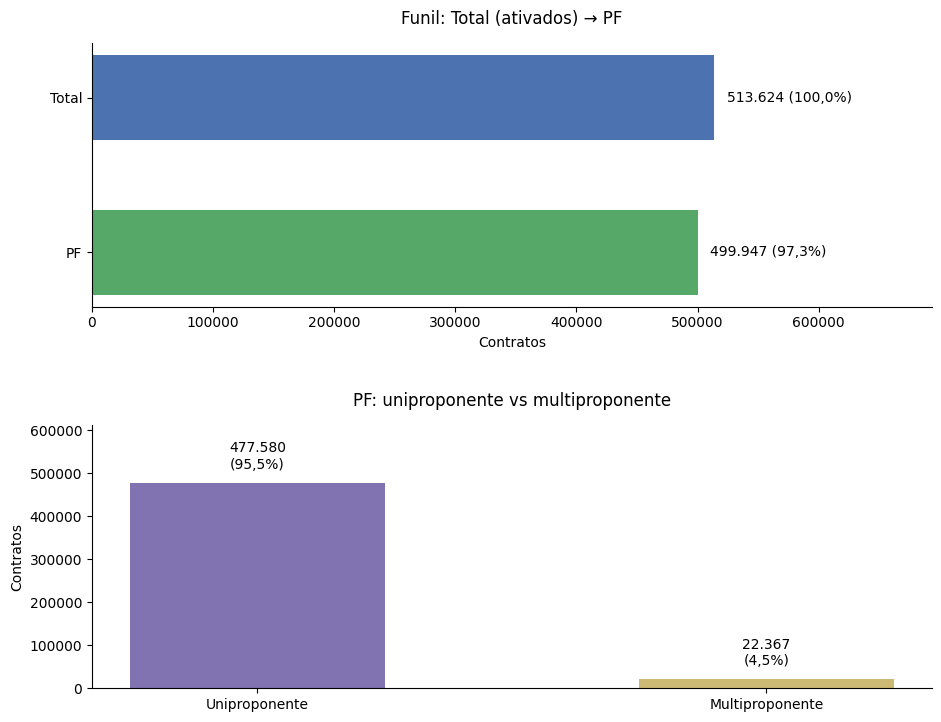

In [199]:
# Grafico do funil: Total (ativados) -> PF -> Uni/Multi
plot_funnel(funnel)


In [200]:
df_pf_act = filter_pf_activated(df_sim_ctr)
df_pf_act = add_days_req_to_act(df_pf_act)
df_pf_act = add_blend_model_columns(df_pf_act)
print(
    f"Universo do monitor: {len(df_pf_act):,} contratos PF "
    f"(uniproponente={(df_pf_act['is_multiproponente'] == 0).sum():,} | "
    f"multiproponente={(df_pf_act['is_multiproponente'] == 1).sum():,})"
)
display(
    df_pf_act.groupby(["modelo", "is_fallback"], dropna=False)
    .size()
    .rename("qtd")
    .reset_index()
    .sort_values(["modelo", "is_fallback"])
)


Universo do monitor: 499,947 contratos PF (uniproponente=477,580 | multiproponente=22,367)


,modelo,is_fallback,qtd
0,Blend2,0,349884
1,Blend2,1,2610
2,Blend3,0,62739
3,Blend3,1,116
4,Blend4,0,4175
5,Blend4,1,54
6,Outros,0,80361
7,Outros,1,8


## Tempo de solicitação (prazo)

Faixas fixas: 0, 1-2, 3-6, 7-14 e >=15 dias entre solicitação e ativação.


In [201]:
df_pf_act = add_sla_bin(df_pf_act)
display(sla_bin_volume(df_pf_act).style.format({"qtd": "{:,.0f}", "%": "{:.1%}"}))


,qtd,%
faixa_prazo,,
0,"210,410",42.1%
1-2,"150,875",30.2%
3-6,"89,882",18.0%
7-14,"37,244",7.4%
>=15,"11,536",2.3%


faixa_prazo,0,1-2,3-6,7-14,>=15
safra_ativacao,,,,,
2025-09-01,5877,5212,3826,1798,620
2025-10-01,5834,5669,3117,1582,576
2025-11-01,5272,4379,2965,1390,482
2025-12-01,4696,3486,2627,1131,408
2026-01-01,6807,5260,2785,1256,573
2026-02-01,4949,4101,2605,1411,559
2026-03-01,5575,4898,3538,1628,556
2026-04-01,5493,4798,3177,1761,662
2026-05-01,5661,4885,3106,1720,663


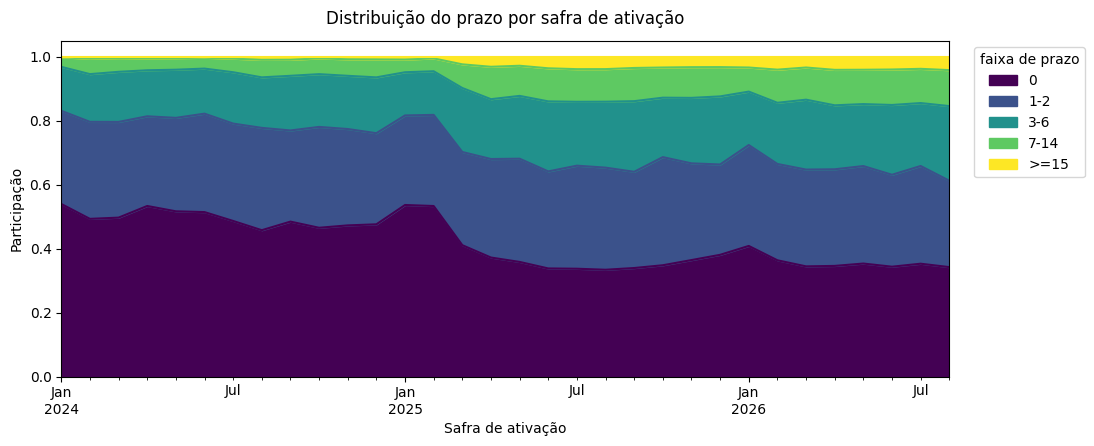

In [202]:
sla_by_safra = (
    df_pf_act.groupby(["safra_ativacao", "faixa_prazo"], dropna=False)
    .size()
    .unstack(fill_value=0)
)
sla_by_safra.index.name = "safra_ativacao"
sla_by_safra.columns.name = "faixa_prazo"
display(sla_by_safra.tail(12))

sla_share = sla_by_safra.div(sla_by_safra.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(12, 4.8))
sla_share.plot(kind="area", stacked=True, ax=ax, colormap="viridis")
ax.set_ylabel("Participação")
ax.set_xlabel("Safra de ativação")
ax.set_title("Distribuição do prazo por safra de ativação", pad=12)
ax.legend(title="faixa de prazo", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(left=0.08, right=0.82, top=0.88, bottom=0.18)
plt.show()


## Uniproponente vs Multiproponente

Uniproponente: visão completa. Multiproponente: visão básica (mesmos indicadores, menos cortes).

In [203]:
df_uni = df_pf_act[df_pf_act["is_multiproponente"] == 0].copy()
df_multi = df_pf_act[df_pf_act["is_multiproponente"] == 1].copy()

print(f"Uniproponente: {len(df_uni):,} | Multiproponente: {len(df_multi):,}")
display(
    pd.DataFrame(
        {
            "segmento": ["Uniproponente", "Multiproponente"],
            "qtd": [len(df_uni), len(df_multi)],
            "% dos PF ativados": [
                len(df_uni) / len(df_pf_act),
                len(df_multi) / len(df_pf_act),
            ],
        }
    ).style.format({"qtd": "{:,.0f}", "% dos PF ativados": "{:.1%}"})
)


Uniproponente: 477,580 | Multiproponente: 22,367


,segmento,qtd,% dos PF ativados
0,Uniproponente,"477,580",95.5%
1,Multiproponente,"22,367",4.5%


## Inadimplência e Volumetria Maturada

Indicadores já na base: PC competência 2m/3m, PC caixa 2m/3m, PD 2m/3m. Valor nulo ≈ não maturada; taxa = média nos não-nulos; volumetria maturada = contagem de não-nulos.

In [204]:
print("Visão geral — Uniproponente")
display(
    summarize_targets(df_uni).style.format(
        {
            "qtd_ativados": "{:,.0f}",
            "qtd_maturados": "{:,.0f}",
            "cobertura_maturidade": "{:.1%}",
            "taxa": "{:.2%}",
        }
    )
)

Visão geral — Uniproponente


,indicador,qtd_ativados,qtd_maturados,cobertura_maturidade,taxa
0,PC competência 2m,"477,580","424,590",88.9%,8.58%
1,PC competência 3m,"477,580","409,140",85.7%,8.59%
2,PC caixa 2m,"477,580","455,198",95.3%,6.61%
3,PC caixa 3m,"477,580","440,079",92.1%,6.76%
4,PD 2m,"477,580","455,198",95.3%,1.61%
5,PD 3m,"477,580","440,079",92.1%,1.67%


In [205]:
print("Visão geral — Multiproponente")
display(
    summarize_targets(df_multi).style.format(
        {
            "qtd_ativados": "{:,.0f}",
            "qtd_maturados": "{:,.0f}",
            "cobertura_maturidade": "{:.1%}",
            "taxa": "{:.2%}",
        }
    )
)

Visão geral — Multiproponente


,indicador,qtd_ativados,qtd_maturados,cobertura_maturidade,taxa
0,PC competência 2m,"22,367","20,646",92.3%,4.30%
1,PC competência 3m,"22,367","20,205",90.3%,4.34%
2,PC caixa 2m,"22,367","21,673",96.9%,3.32%
3,PC caixa 3m,"22,367","21,192",94.7%,3.37%
4,PD 2m,"22,367","21,673",96.9%,0.54%
5,PD 3m,"22,367","21,192",94.7%,0.56%


,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"16,221","16,221","1,378",8.50%,100.0%
2024-02-01 00:00:00,"14,038","14,038","1,256",8.95%,100.0%
2024-03-01 00:00:00,"14,392","14,392","1,212",8.42%,100.0%
2024-04-01 00:00:00,"15,034","15,034","1,257",8.36%,100.0%
2024-05-01 00:00:00,"14,270","14,270","1,094",7.67%,100.0%
2024-06-01 00:00:00,"13,669","13,669","1,036",7.58%,100.0%
2024-07-01 00:00:00,"15,110","15,110","1,266",8.38%,100.0%
2024-08-01 00:00:00,"14,710","14,710","1,290",8.77%,100.0%
2024-09-01 00:00:00,"13,965","13,965","1,244",8.91%,100.0%


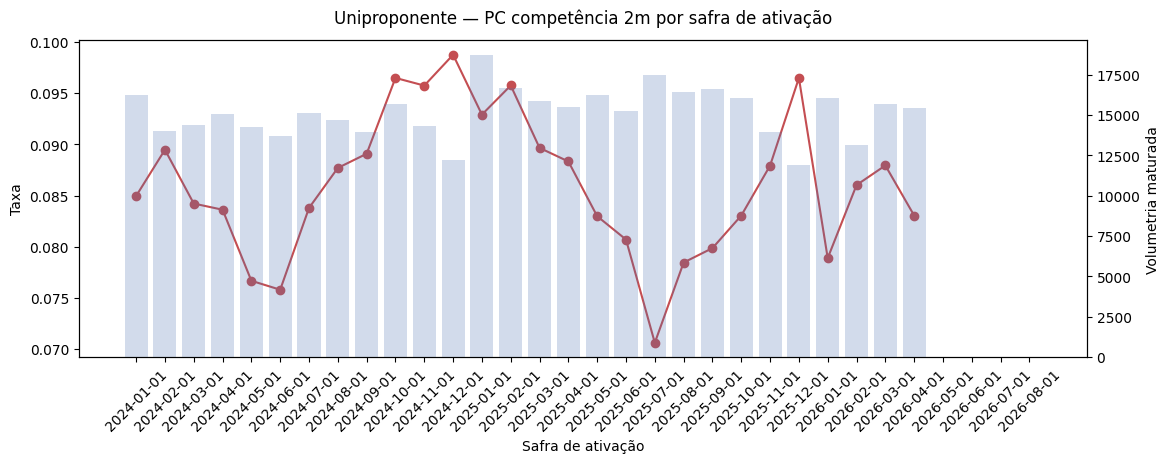

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"16,221","16,221","1,378",8.50%,100.0%
2024-02-01 00:00:00,"14,038","14,038","1,256",8.95%,100.0%
2024-03-01 00:00:00,"14,392","14,392","1,212",8.42%,100.0%
2024-04-01 00:00:00,"15,034","15,034","1,257",8.36%,100.0%
2024-05-01 00:00:00,"14,270","14,270","1,094",7.67%,100.0%
2024-06-01 00:00:00,"13,669","13,669","1,036",7.58%,100.0%
2024-07-01 00:00:00,"15,110","15,110","1,266",8.38%,100.0%
2024-08-01 00:00:00,"14,710","14,710","1,290",8.77%,100.0%
2024-09-01 00:00:00,"13,965","13,965","1,244",8.91%,100.0%


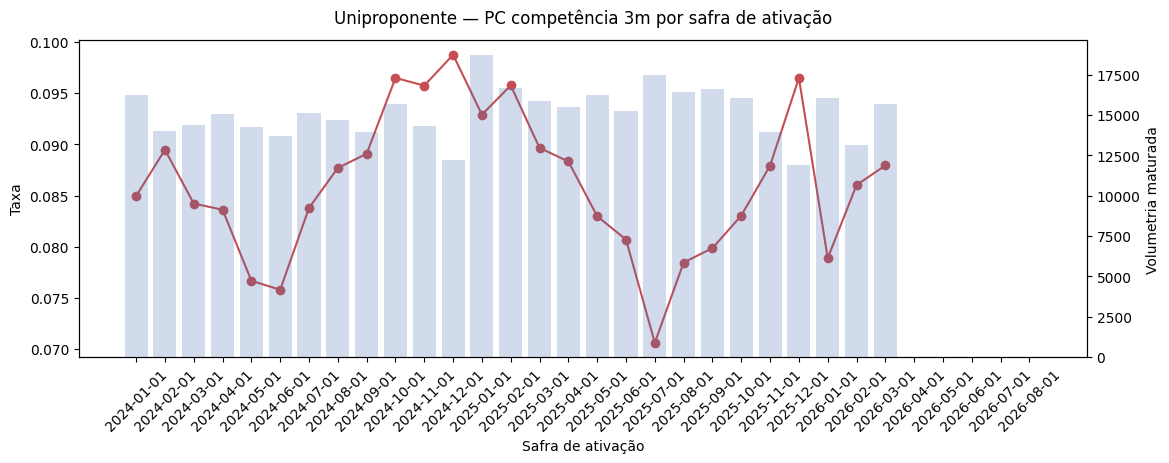

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"16,221","16,221","1,059",6.53%,100.0%
2024-02-01 00:00:00,"14,038","14,038","1,000",7.12%,100.0%
2024-03-01 00:00:00,"14,392","14,392","1,012",7.03%,100.0%
2024-04-01 00:00:00,"15,034","15,034","1,023",6.80%,100.0%
2024-05-01 00:00:00,"14,270","14,270",896,6.28%,100.0%
2024-06-01 00:00:00,"13,669","13,669",839,6.14%,100.0%
2024-07-01 00:00:00,"15,110","15,110","1,033",6.84%,100.0%
2024-08-01 00:00:00,"14,710","14,710","1,062",7.22%,100.0%
2024-09-01 00:00:00,"13,965","13,965","1,000",7.16%,100.0%


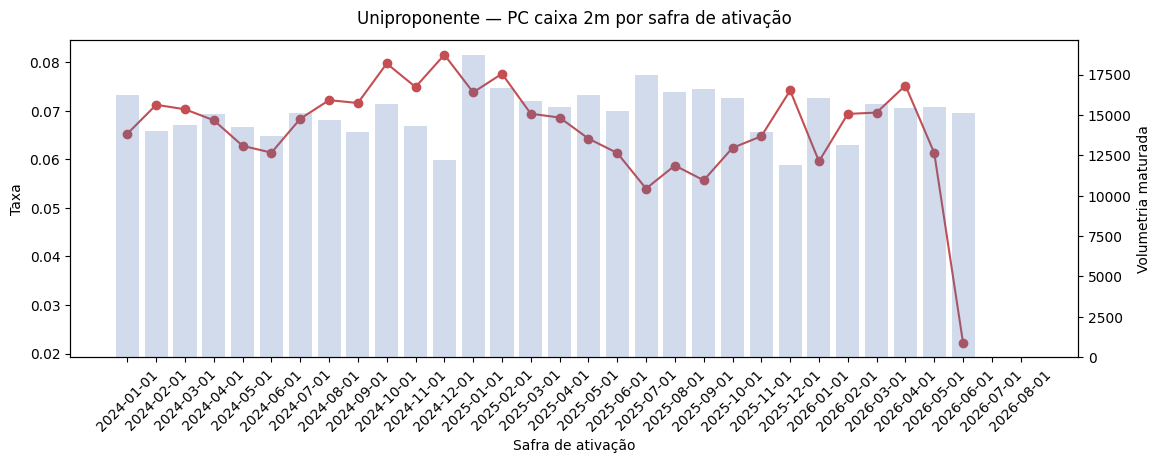

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"16,221","16,221","1,059",6.53%,100.0%
2024-02-01 00:00:00,"14,038","14,038","1,000",7.12%,100.0%
2024-03-01 00:00:00,"14,392","14,392","1,012",7.03%,100.0%
2024-04-01 00:00:00,"15,034","15,034","1,023",6.80%,100.0%
2024-05-01 00:00:00,"14,270","14,270",896,6.28%,100.0%
2024-06-01 00:00:00,"13,669","13,669",839,6.14%,100.0%
2024-07-01 00:00:00,"15,110","15,110","1,033",6.84%,100.0%
2024-08-01 00:00:00,"14,710","14,710","1,062",7.22%,100.0%
2024-09-01 00:00:00,"13,965","13,965","1,000",7.16%,100.0%


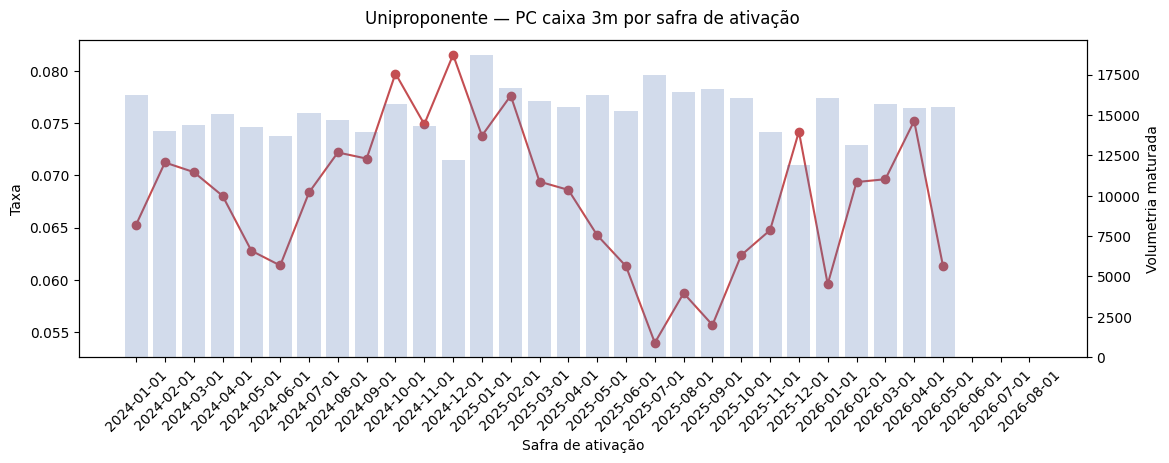

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"16,221","16,221",201,1.24%,100.0%
2024-02-01 00:00:00,"14,038","14,038",189,1.35%,100.0%
2024-03-01 00:00:00,"14,392","14,392",230,1.60%,100.0%
2024-04-01 00:00:00,"15,034","15,034",227,1.51%,100.0%
2024-05-01 00:00:00,"14,270","14,270",176,1.23%,100.0%
2024-06-01 00:00:00,"13,669","13,669",171,1.25%,100.0%
2024-07-01 00:00:00,"15,110","15,110",204,1.35%,100.0%
2024-08-01 00:00:00,"14,710","14,710",246,1.67%,100.0%
2024-09-01 00:00:00,"13,965","13,965",225,1.61%,100.0%


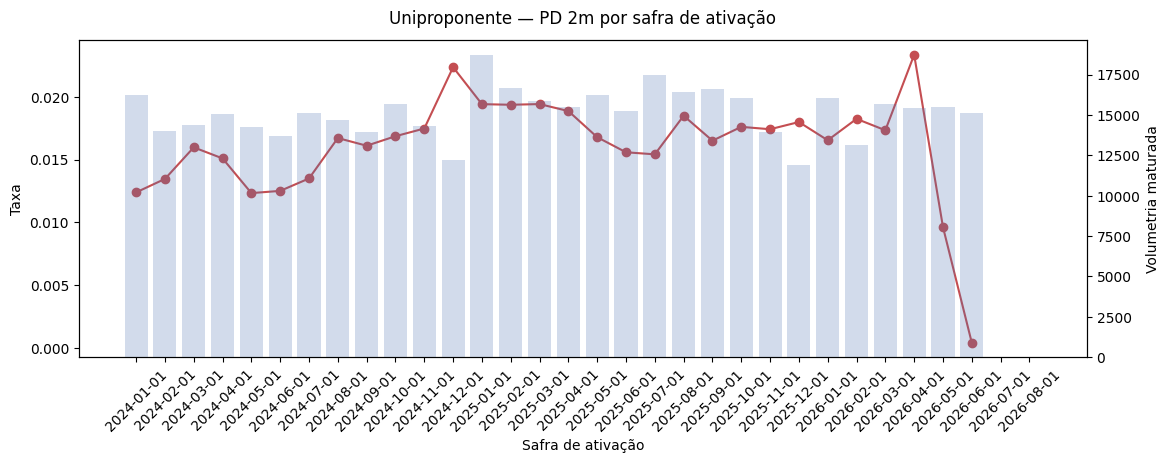

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"16,221","16,221",201,1.24%,100.0%
2024-02-01 00:00:00,"14,038","14,038",189,1.35%,100.0%
2024-03-01 00:00:00,"14,392","14,392",230,1.60%,100.0%
2024-04-01 00:00:00,"15,034","15,034",227,1.51%,100.0%
2024-05-01 00:00:00,"14,270","14,270",176,1.23%,100.0%
2024-06-01 00:00:00,"13,669","13,669",171,1.25%,100.0%
2024-07-01 00:00:00,"15,110","15,110",204,1.35%,100.0%
2024-08-01 00:00:00,"14,710","14,710",246,1.67%,100.0%
2024-09-01 00:00:00,"13,965","13,965",225,1.61%,100.0%


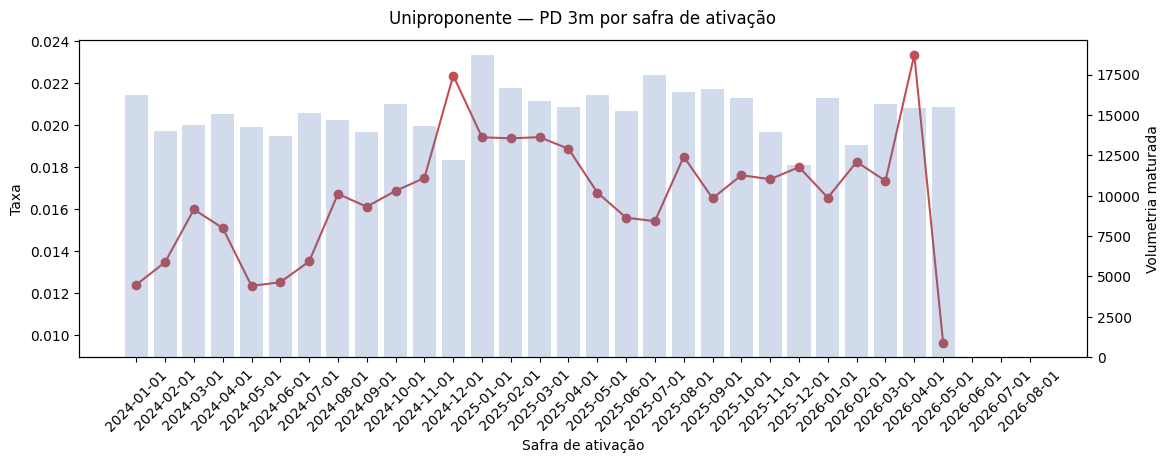

In [206]:
for target in TARGET_COLS:
    perf = cohort_perf(df_uni, target)
    display(
        perf.style.format(
            {
                "qtd_ativados": "{:,.0f}",
                "qtd_maturados": "{:,.0f}",
                "qtd_maus": "{:,.0f}",
                "taxa": "{:.2%}",
                "cobertura_maturidade": "{:.1%}",
            }
        )
    )
    plot_cohort_rates(
        perf,
        title=f"Uniproponente — {TARGET_LABELS[target]} por safra de ativação",
    )


indicador,PC caixa 2m,PC caixa 3m,PC competência 2m,PC competência 3m,PD 2m,PD 3m
faixa_prazo,,,,,,
0,5.46%,5.55%,7.07%,7.05%,1.22%,1.25%
1-2,7.03%,7.20%,9.14%,9.15%,1.72%,1.77%
3-6,7.87%,8.11%,10.32%,10.38%,2.04%,2.12%
7-14,8.32%,8.60%,10.98%,11.12%,2.35%,2.47%
>=15,7.24%,7.54%,9.32%,9.55%,1.94%,2.07%


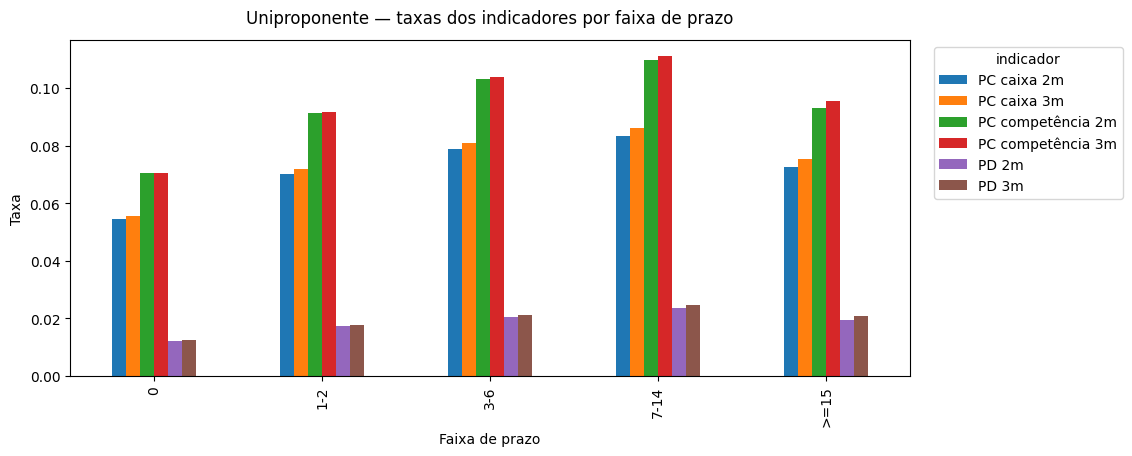

In [207]:
uni_by_sla = []
for target in TARGET_COLS:
    g = df_uni.groupby("faixa_prazo", dropna=False)[target]
    uni_by_sla.append(
        pd.DataFrame(
            {
                "indicador": TARGET_LABELS[target],
                "qtd_maturados": g.apply(lambda s: s.notna().sum()),
                "taxa": g.mean(),
            }
        ).reset_index()
    )

uni_sla_rates = pd.concat(uni_by_sla, ignore_index=True)
pivot_taxa = uni_sla_rates.pivot(index="faixa_prazo", columns="indicador", values="taxa")
pivot_taxa.index.name = "faixa_prazo"
pivot_taxa.columns.name = "indicador"
display(pivot_taxa.style.format("{:.2%}"))

fig, ax = plt.subplots(figsize=(12, 4.8))
pivot_taxa.plot(kind="bar", ax=ax)
ax.set_ylabel("Taxa")
ax.set_xlabel("Faixa de prazo")
ax.set_title("Uniproponente — taxas dos indicadores por faixa de prazo", pad=12)
ax.legend(title="indicador", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.subplots_adjust(left=0.08, right=0.78, top=0.88, bottom=0.18)
plt.show()


,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,23,3.10%,100.0%
2025-10-01 00:00:00,713,713,30,4.21%,100.0%
2025-11-01 00:00:00,544,544,24,4.41%,100.0%
2025-12-01 00:00:00,460,460,21,4.57%,100.0%
2026-01-01 00:00:00,606,606,22,3.63%,100.0%
2026-02-01 00:00:00,477,477,16,3.35%,100.0%
2026-03-01 00:00:00,513,513,15,2.92%,100.0%
2026-04-01 00:00:00,441,441,11,2.49%,100.0%
2026-05-01 00:00:00,546,0,,,0.0%


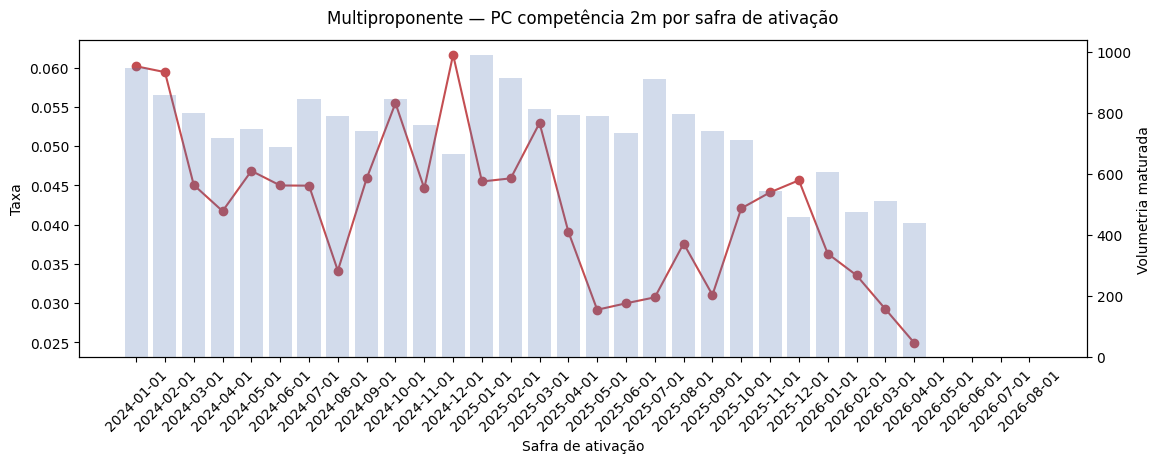

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,23,3.10%,100.0%
2025-10-01 00:00:00,713,713,30,4.21%,100.0%
2025-11-01 00:00:00,544,544,24,4.41%,100.0%
2025-12-01 00:00:00,460,460,21,4.57%,100.0%
2026-01-01 00:00:00,606,606,22,3.63%,100.0%
2026-02-01 00:00:00,477,477,16,3.35%,100.0%
2026-03-01 00:00:00,513,513,15,2.92%,100.0%
2026-04-01 00:00:00,441,0,,,0.0%
2026-05-01 00:00:00,546,0,,,0.0%


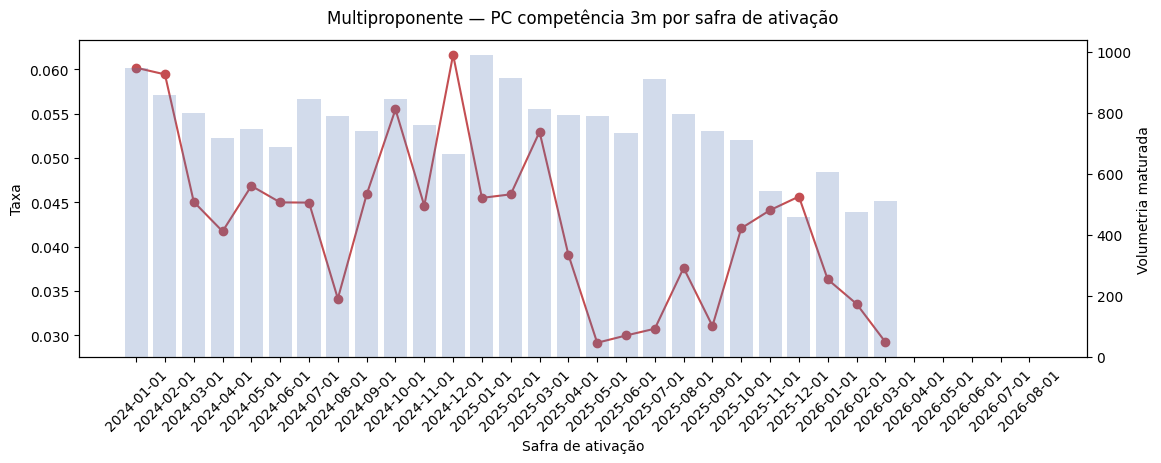

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,18,2.43%,100.0%
2025-10-01 00:00:00,713,713,22,3.09%,100.0%
2025-11-01 00:00:00,544,544,13,2.39%,100.0%
2025-12-01 00:00:00,460,460,13,2.83%,100.0%
2026-01-01 00:00:00,606,606,18,2.97%,100.0%
2026-02-01 00:00:00,477,477,13,2.73%,100.0%
2026-03-01 00:00:00,513,513,13,2.53%,100.0%
2026-04-01 00:00:00,441,441,11,2.49%,100.0%
2026-05-01 00:00:00,546,546,11,2.01%,100.0%


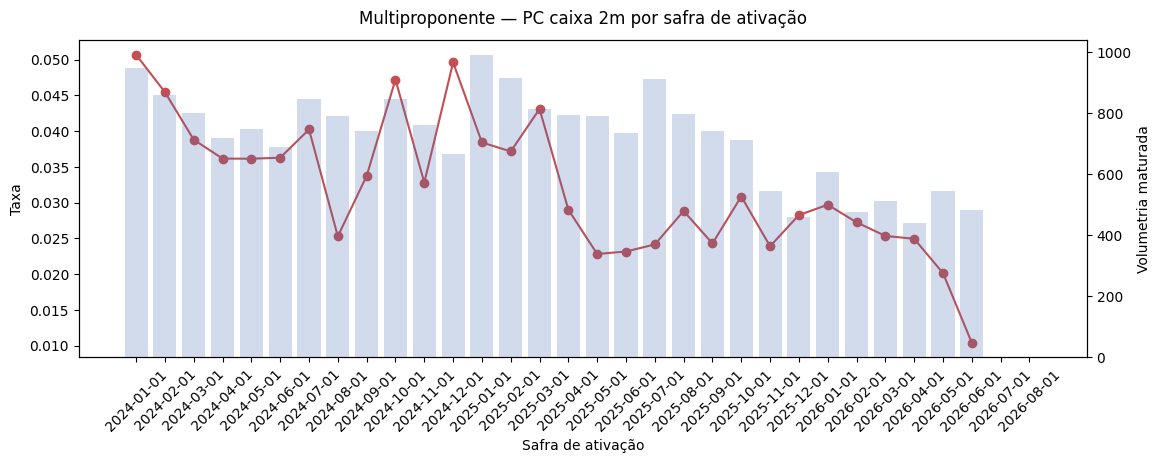

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,18,2.43%,100.0%
2025-10-01 00:00:00,713,713,22,3.09%,100.0%
2025-11-01 00:00:00,544,544,13,2.39%,100.0%
2025-12-01 00:00:00,460,460,13,2.83%,100.0%
2026-01-01 00:00:00,606,606,18,2.97%,100.0%
2026-02-01 00:00:00,477,477,13,2.73%,100.0%
2026-03-01 00:00:00,513,513,13,2.53%,100.0%
2026-04-01 00:00:00,441,441,11,2.49%,100.0%
2026-05-01 00:00:00,546,546,11,2.01%,100.0%


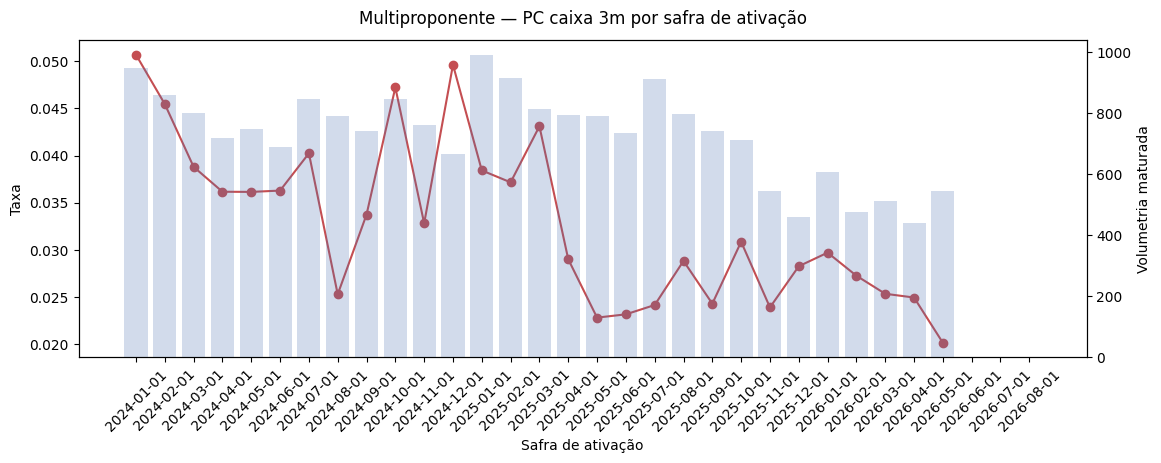

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,3,0.40%,100.0%
2025-10-01 00:00:00,713,713,2,0.28%,100.0%
2025-11-01 00:00:00,544,544,3,0.55%,100.0%
2025-12-01 00:00:00,460,460,4,0.87%,100.0%
2026-01-01 00:00:00,606,606,2,0.33%,100.0%
2026-02-01 00:00:00,477,477,4,0.84%,100.0%
2026-03-01 00:00:00,513,513,3,0.58%,100.0%
2026-04-01 00:00:00,441,441,1,0.23%,100.0%
2026-05-01 00:00:00,546,546,0,0.00%,100.0%


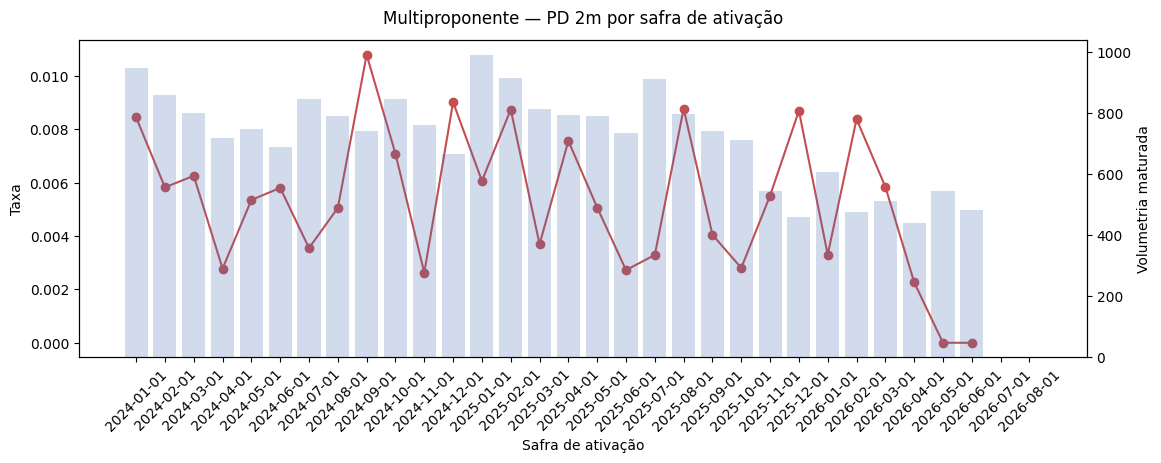

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,3,0.40%,100.0%
2025-10-01 00:00:00,713,713,2,0.28%,100.0%
2025-11-01 00:00:00,544,544,3,0.55%,100.0%
2025-12-01 00:00:00,460,460,4,0.87%,100.0%
2026-01-01 00:00:00,606,606,2,0.33%,100.0%
2026-02-01 00:00:00,477,477,4,0.84%,100.0%
2026-03-01 00:00:00,513,513,3,0.58%,100.0%
2026-04-01 00:00:00,441,441,1,0.23%,100.0%
2026-05-01 00:00:00,546,546,0,0.00%,100.0%


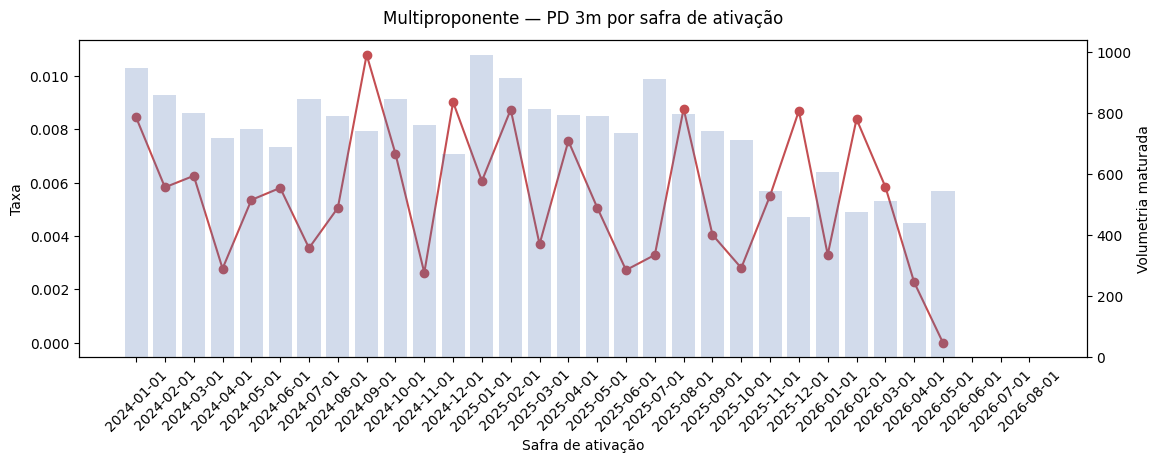

In [208]:
for target in TARGET_COLS:
    perf = cohort_perf(df_multi, target)
    display(
        perf.tail(12).style.format(
            {
                "qtd_ativados": "{:,.0f}",
                "qtd_maturados": "{:,.0f}",
                "qtd_maus": "{:,.0f}",
                "taxa": "{:.2%}",
                "cobertura_maturidade": "{:.1%}",
            }
        )
    )
    plot_cohort_rates(
        perf,
        title=f"Multiproponente — {TARGET_LABELS[target]} por safra de ativação",
    )


## Modelos Blend

- modelo: Blend2/Blend3/Blend4/Outros (mapa modeloBlend + bureau_nm)
- is_fallback: regra SQL — 1 se modeloBlend ou bureau_nm em (BVS_CUSTOM_V2, HFT1, BVS_CUSTOM, HVA4); senão 0

Plots: Blend2 e Blend3 com is_fallback = 0 (uniproponente). Multiproponente em bloco único. is_fallback = 1 não é plotado.


,modelo,qtd,segmento,%
0,Blend2,"342,986",Uniproponente,68.6%
1,Blend3,"62,737",Uniproponente,12.5%
2,Multiproponente (todos),"22,367",Multiproponente,4.5%


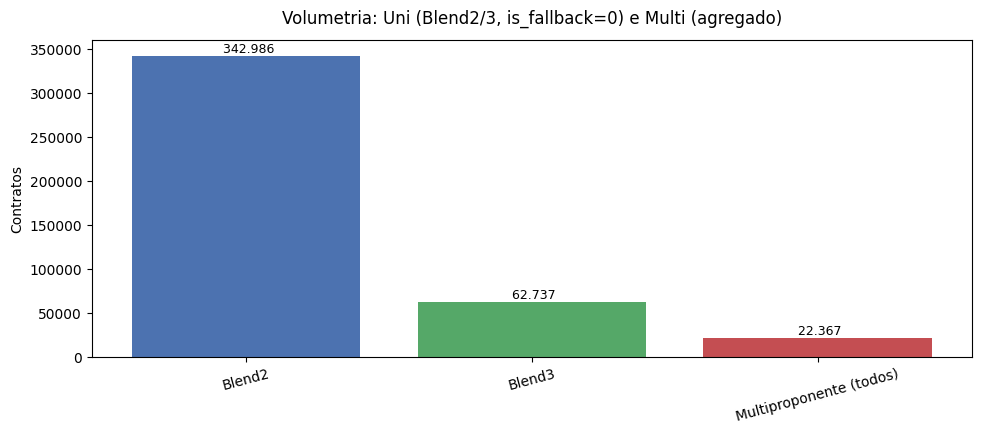

In [209]:
df_uni_blend = df_pf_act[
    (df_pf_act["is_multiproponente"] == 0)
    & (df_pf_act["is_fallback"] == 0)
    & (df_pf_act["modelo"].isin(BLEND_MODELS_PLOT))
].copy()
df_multi_all = df_pf_act[df_pf_act["is_multiproponente"] == 1].copy()

vol_uni = (
    df_uni_blend.groupby("modelo", dropna=False)
    .size()
    .rename("qtd")
    .reindex(BLEND_MODELS_PLOT, fill_value=0)
    .to_frame()
    .assign(segmento="Uniproponente")
    .reset_index()
)
vol_multi = pd.DataFrame(
    [{"modelo": "Multiproponente (todos)", "qtd": len(df_multi_all), "segmento": "Multiproponente"}]
)
vol_plot = pd.concat([vol_uni, vol_multi], ignore_index=True)
vol_plot["%"] = vol_plot["qtd"] / len(df_pf_act) if len(df_pf_act) else np.nan
display(vol_plot.style.format({"qtd": "{:,.0f}", "%": "{:.1%}"}))

fig, ax = plt.subplots(figsize=(10, 4.8))
labels = vol_plot["modelo"].tolist()
ax.bar(labels, vol_plot["qtd"], color=["#4C72B0", "#55A868", "#C44E52"][: len(labels)])
ax.set_ylabel("Contratos")
ax.set_xlabel("")
ax.set_title("Volumetria: Uni (Blend2/3, is_fallback=0) e Multi (agregado)", pad=12)
ax.tick_params(axis="x", rotation=15)
for i, n in enumerate(vol_plot["qtd"]):
    ax.text(i, n, f" {n:,.0f}".replace(",", "."), ha="center", va="bottom", fontsize=9)
fig.subplots_adjust(left=0.08, right=0.96, top=0.88, bottom=0.22)
plt.show()

## Inadimplência e Volumetria Maturada por Modelo Blend

Uniproponente: Blend2 e Blend3 com is_fallback = 0 (Blend4 comentado em BLEND_MODELS_PLOT).
Multiproponente: bloco único, sem corte por modelo ou is_fallback. is_fallback = 1 não é plotado.

In [210]:
# Resumo geral: Uni por modelo (Blend2/3, is_fallback=0) + Multi agregado
rows = []
for modelo in BLEND_MODELS_PLOT:
    d = df_pf_act[
        (df_pf_act["modelo"] == modelo)
        & (df_pf_act["is_fallback"] == 0)
        & (df_pf_act["is_multiproponente"] == 0)
    ]
    if d.empty:
        continue
    summ = summarize_targets(d)
    summ.insert(0, "recorte", f"{modelo} | Uni | is_fallback=0")
    rows.append(summ)

summ_multi = summarize_targets(df_pf_act[df_pf_act["is_multiproponente"] == 1])
summ_multi.insert(0, "recorte", "Multiproponente (todos)")
rows.append(summ_multi)

resumo_blend = pd.concat(rows, ignore_index=True)
display(
    resumo_blend.style.format(
        {
            "qtd_ativados": "{:,.0f}",
            "qtd_maturados": "{:,.0f}",
            "cobertura_maturidade": "{:.1%}",
            "taxa": "{:.2%}",
        }
    )
)


,recorte,indicador,qtd_ativados,qtd_maturados,cobertura_maturidade,taxa
0,Blend2 | Uni | is_fallback=0,PC competência 2m,"342,986","339,835",99.1%,8.11%
1,Blend2 | Uni | is_fallback=0,PC competência 3m,"342,986","338,195",98.6%,8.11%
2,Blend2 | Uni | is_fallback=0,PC caixa 2m,"342,986","342,703",99.9%,6.31%
3,Blend2 | Uni | is_fallback=0,PC caixa 3m,"342,986","341,270",99.5%,6.33%
4,Blend2 | Uni | is_fallback=0,PD 2m,"342,986","342,703",99.9%,1.56%
5,Blend2 | Uni | is_fallback=0,PD 3m,"342,986","341,270",99.5%,1.57%
6,Blend3 | Uni | is_fallback=0,PC competência 2m,"62,737","17,270",27.5%,8.12%
7,Blend3 | Uni | is_fallback=0,PC competência 3m,"62,737","3,531",5.6%,7.45%
8,Blend3 | Uni | is_fallback=0,PC caixa 2m,"62,737","44,932",71.6%,5.36%
9,Blend3 | Uni | is_fallback=0,PC caixa 3m,"62,737","31,286",49.9%,6.73%


Blend2 | Uni | is_fallback = 0
Uniproponente: 342,986


,indicador,qtd_ativados,qtd_maturados,cobertura_maturidade,taxa
0,PC competência 2m,"342,986","339,835",99.1%,8.11%
1,PC competência 3m,"342,986","338,195",98.6%,8.11%
2,PC caixa 2m,"342,986","342,703",99.9%,6.31%
3,PC caixa 3m,"342,986","341,270",99.5%,6.33%
4,PD 2m,"342,986","342,703",99.9%,1.56%
5,PD 3m,"342,986","341,270",99.5%,1.57%


,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"7,462","7,462",496,6.65%,100.0%
2024-02-01 00:00:00,"8,864","8,864",665,7.50%,100.0%
2024-03-01 00:00:00,"9,087","9,087",647,7.12%,100.0%
2024-04-01 00:00:00,"9,634","9,634",708,7.35%,100.0%
2024-05-01 00:00:00,"9,736","9,736",637,6.54%,100.0%
2024-06-01 00:00:00,"9,448","9,448",607,6.42%,100.0%
2024-07-01 00:00:00,"10,548","10,548",747,7.08%,100.0%
2024-08-01 00:00:00,"9,892","9,892",729,7.37%,100.0%
2024-09-01 00:00:00,"9,284","9,284",685,7.38%,100.0%


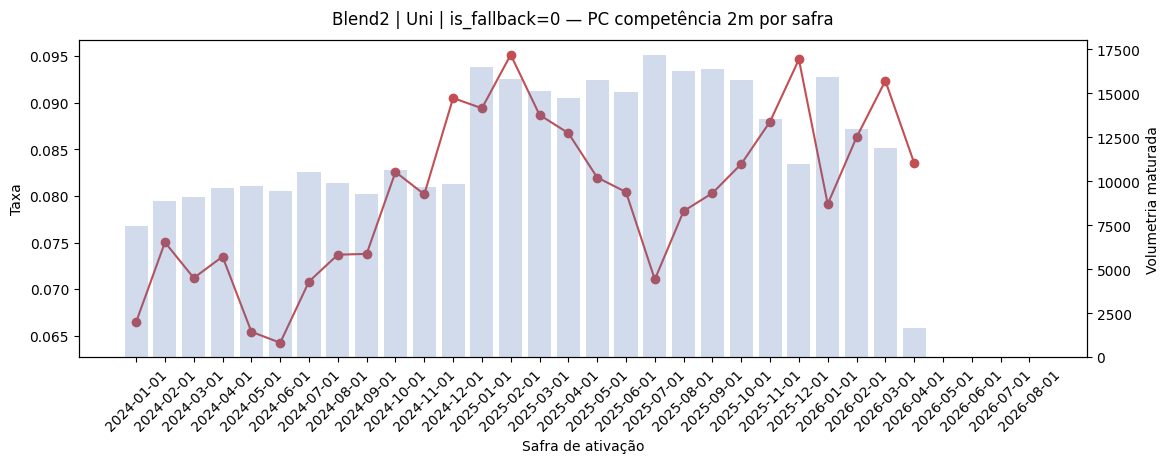

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"7,462","7,462",496,6.65%,100.0%
2024-02-01 00:00:00,"8,864","8,864",665,7.50%,100.0%
2024-03-01 00:00:00,"9,087","9,087",647,7.12%,100.0%
2024-04-01 00:00:00,"9,634","9,634",708,7.35%,100.0%
2024-05-01 00:00:00,"9,736","9,736",637,6.54%,100.0%
2024-06-01 00:00:00,"9,448","9,448",607,6.42%,100.0%
2024-07-01 00:00:00,"10,548","10,548",747,7.08%,100.0%
2024-08-01 00:00:00,"9,892","9,892",729,7.37%,100.0%
2024-09-01 00:00:00,"9,284","9,284",685,7.38%,100.0%


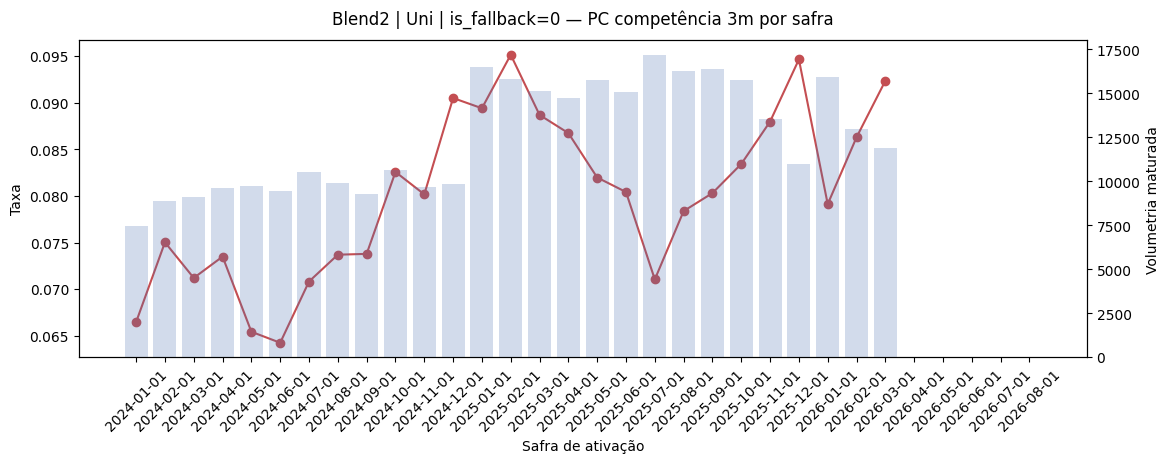

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"7,462","7,462",371,4.97%,100.0%
2024-02-01 00:00:00,"8,864","8,864",512,5.78%,100.0%
2024-03-01 00:00:00,"9,087","9,087",544,5.99%,100.0%
2024-04-01 00:00:00,"9,634","9,634",575,5.97%,100.0%
2024-05-01 00:00:00,"9,736","9,736",514,5.28%,100.0%
2024-06-01 00:00:00,"9,448","9,448",501,5.30%,100.0%
2024-07-01 00:00:00,"10,548","10,548",606,5.75%,100.0%
2024-08-01 00:00:00,"9,892","9,892",610,6.17%,100.0%
2024-09-01 00:00:00,"9,284","9,284",549,5.91%,100.0%


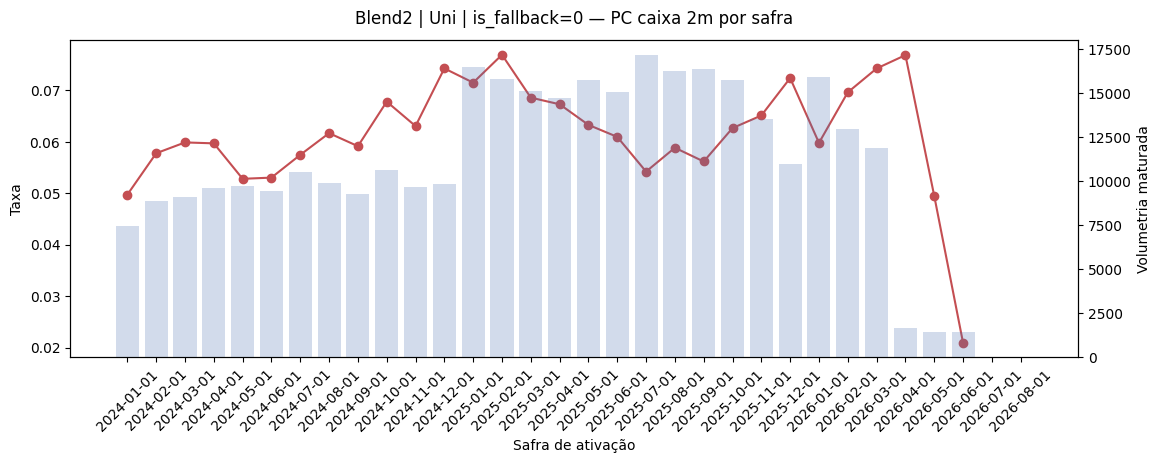

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"7,462","7,462",371,4.97%,100.0%
2024-02-01 00:00:00,"8,864","8,864",512,5.78%,100.0%
2024-03-01 00:00:00,"9,087","9,087",544,5.99%,100.0%
2024-04-01 00:00:00,"9,634","9,634",575,5.97%,100.0%
2024-05-01 00:00:00,"9,736","9,736",514,5.28%,100.0%
2024-06-01 00:00:00,"9,448","9,448",501,5.30%,100.0%
2024-07-01 00:00:00,"10,548","10,548",606,5.75%,100.0%
2024-08-01 00:00:00,"9,892","9,892",610,6.17%,100.0%
2024-09-01 00:00:00,"9,284","9,284",549,5.91%,100.0%


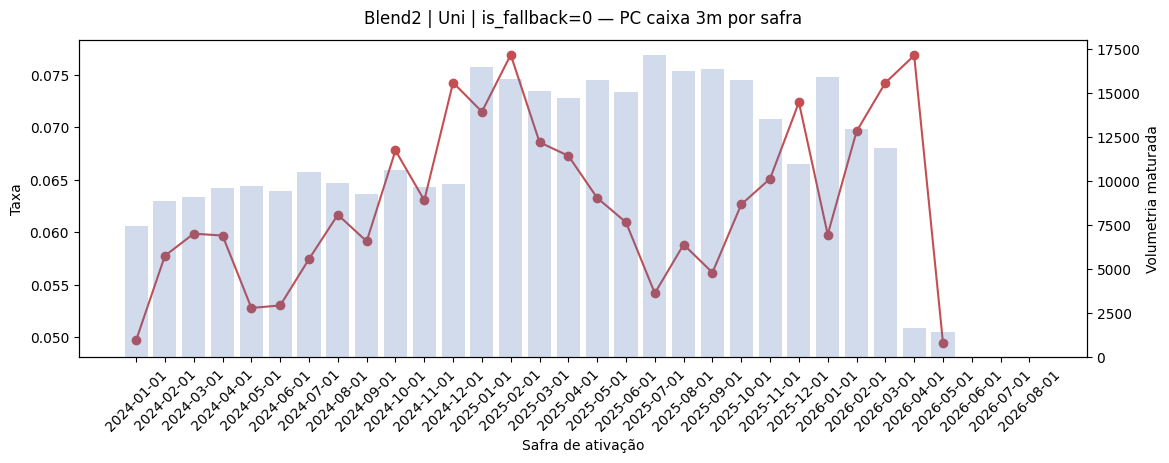

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"7,462","7,462",55,0.74%,100.0%
2024-02-01 00:00:00,"8,864","8,864",86,0.97%,100.0%
2024-03-01 00:00:00,"9,087","9,087",103,1.13%,100.0%
2024-04-01 00:00:00,"9,634","9,634",118,1.22%,100.0%
2024-05-01 00:00:00,"9,736","9,736",95,0.98%,100.0%
2024-06-01 00:00:00,"9,448","9,448",96,1.02%,100.0%
2024-07-01 00:00:00,"10,548","10,548",98,0.93%,100.0%
2024-08-01 00:00:00,"9,892","9,892",140,1.42%,100.0%
2024-09-01 00:00:00,"9,284","9,284",121,1.30%,100.0%


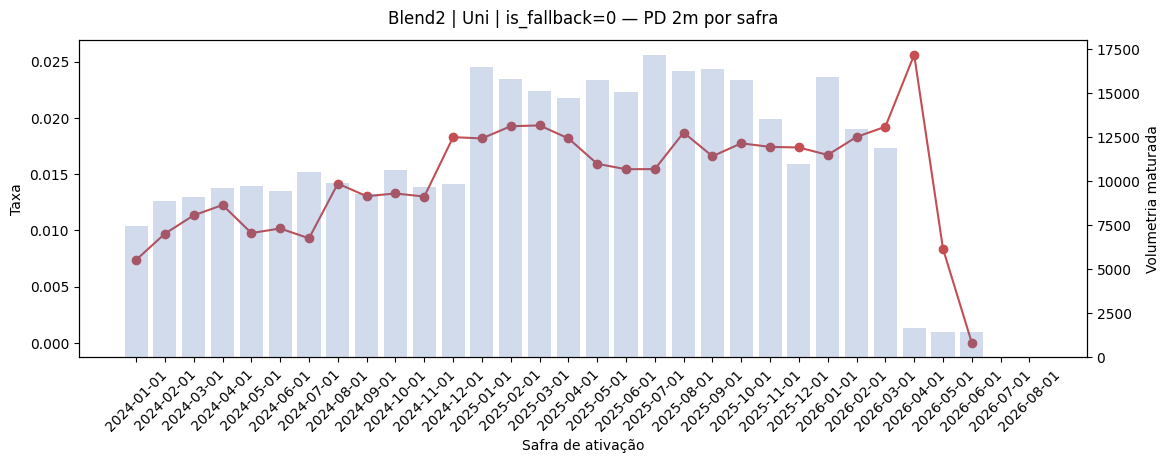

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-01-01 00:00:00,"7,462","7,462",55,0.74%,100.0%
2024-02-01 00:00:00,"8,864","8,864",86,0.97%,100.0%
2024-03-01 00:00:00,"9,087","9,087",103,1.13%,100.0%
2024-04-01 00:00:00,"9,634","9,634",118,1.22%,100.0%
2024-05-01 00:00:00,"9,736","9,736",95,0.98%,100.0%
2024-06-01 00:00:00,"9,448","9,448",96,1.02%,100.0%
2024-07-01 00:00:00,"10,548","10,548",98,0.93%,100.0%
2024-08-01 00:00:00,"9,892","9,892",140,1.42%,100.0%
2024-09-01 00:00:00,"9,284","9,284",121,1.30%,100.0%


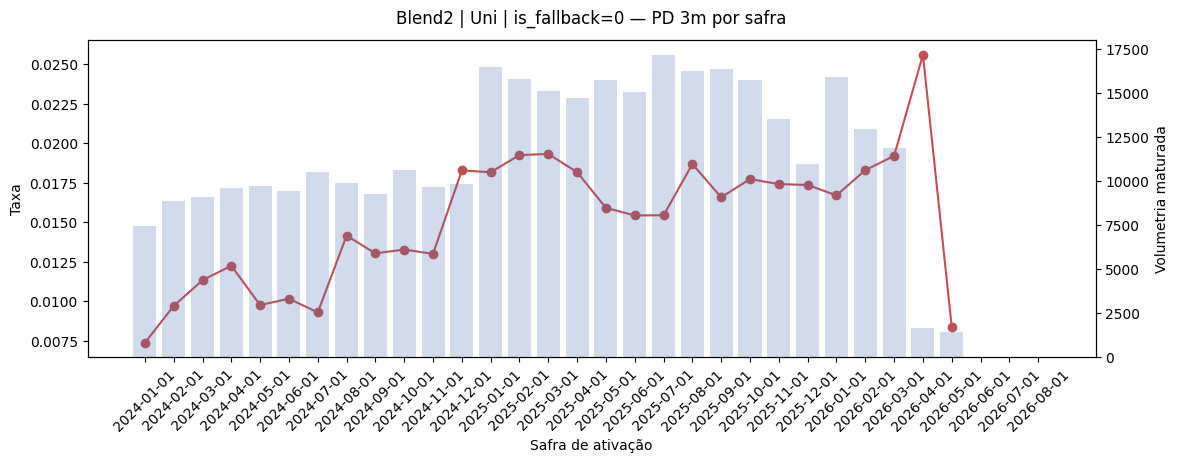

indicador,PC caixa 2m,PC caixa 3m,PC competência 2m,PC competência 3m,PD 2m,PD 3m
faixa_prazo,,,,,,
0,5.14%,5.15%,6.60%,6.60%,1.15%,1.15%
1-2,6.73%,6.75%,8.63%,8.62%,1.67%,1.68%
3-6,7.65%,7.68%,9.84%,9.84%,1.99%,2.00%
7-14,8.00%,8.03%,10.45%,10.48%,2.38%,2.39%
>=15,7.24%,7.25%,9.01%,9.07%,1.91%,1.93%


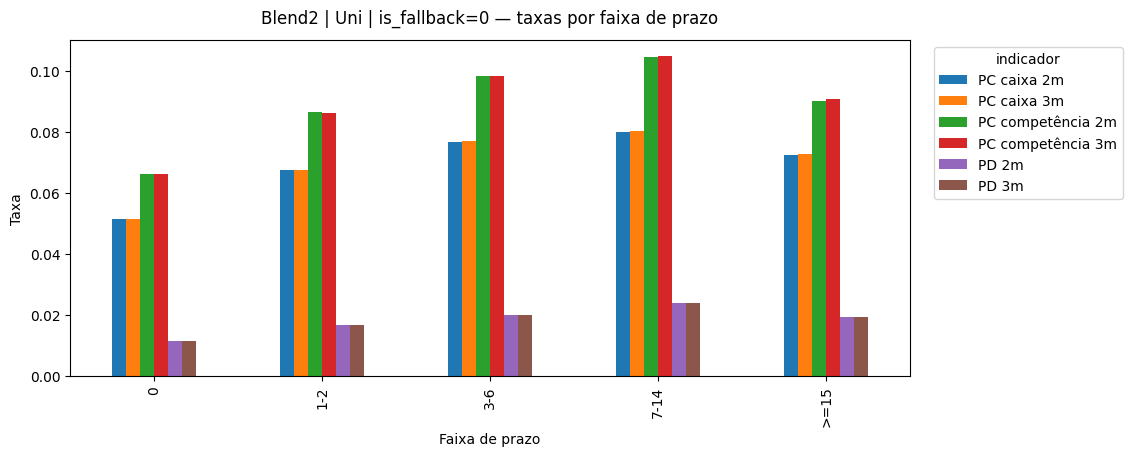

Blend3 | Uni | is_fallback = 0
Uniproponente: 62,737


,indicador,qtd_ativados,qtd_maturados,cobertura_maturidade,taxa
0,PC competência 2m,"62,737","17,270",27.5%,8.12%
1,PC competência 3m,"62,737","3,531",5.6%,7.45%
2,PC caixa 2m,"62,737","44,932",71.6%,5.36%
3,PC caixa 3m,"62,737","31,286",49.9%,6.73%
4,PD 2m,"62,737","44,932",71.6%,1.12%
5,PD 3m,"62,737","31,286",49.9%,1.59%


,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-08-01 00:00:00,2,2,0,0.00%,100.0%
2025-07-01 00:00:00,1,1,0,0.00%,100.0%
2025-11-01 00:00:00,1,1,1,100.00%,100.0%
2026-03-01 00:00:00,"3,527","3,527",262,7.43%,100.0%
2026-04-01 00:00:00,"13,739","13,739","1,139",8.29%,100.0%
2026-05-01 00:00:00,"14,016",0,,,0.0%
2026-06-01 00:00:00,"13,646",0,,,0.0%
2026-07-01 00:00:00,"15,108",0,,,0.0%
2026-08-01 00:00:00,"2,697",0,,,0.0%


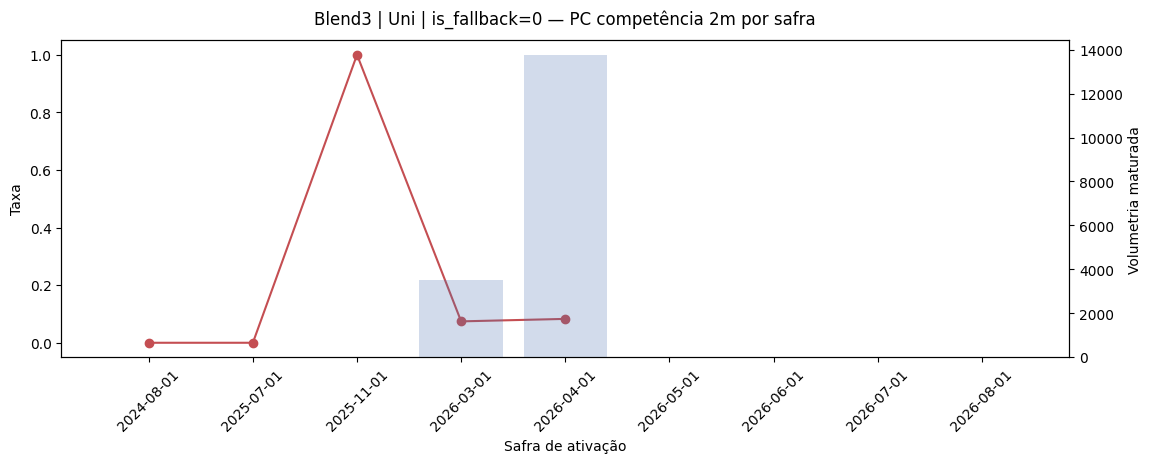

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-08-01 00:00:00,2,2,0,0.00%,100.0%
2025-07-01 00:00:00,1,1,0,0.00%,100.0%
2025-11-01 00:00:00,1,1,1,100.00%,100.0%
2026-03-01 00:00:00,"3,527","3,527",262,7.43%,100.0%
2026-04-01 00:00:00,"13,739",0,,,0.0%
2026-05-01 00:00:00,"14,016",0,,,0.0%
2026-06-01 00:00:00,"13,646",0,,,0.0%
2026-07-01 00:00:00,"15,108",0,,,0.0%
2026-08-01 00:00:00,"2,697",0,,,0.0%


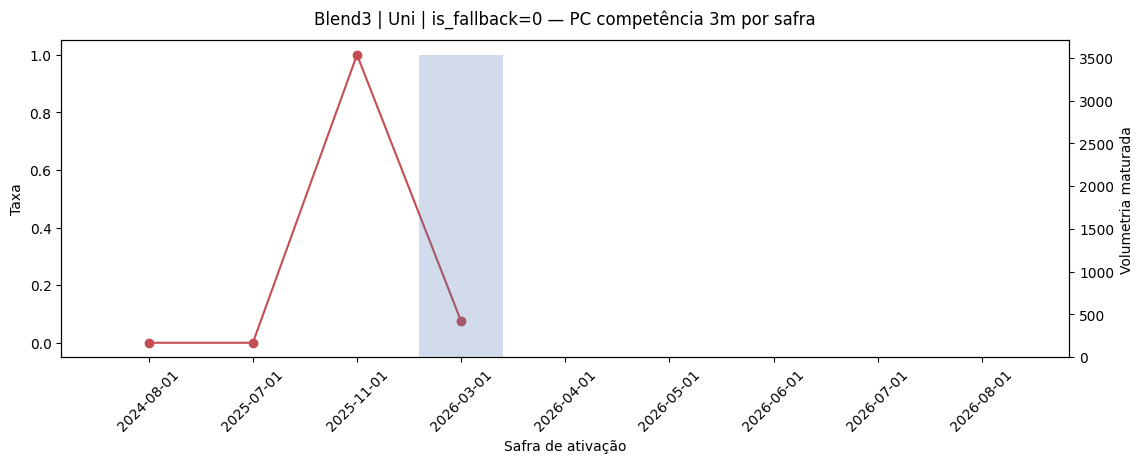

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-08-01 00:00:00,2,2,0,0.00%,100.0%
2025-07-01 00:00:00,1,1,0,0.00%,100.0%
2025-11-01 00:00:00,1,1,1,100.00%,100.0%
2026-03-01 00:00:00,"3,527","3,527",196,5.56%,100.0%
2026-04-01 00:00:00,"13,739","13,739","1,030",7.50%,100.0%
2026-05-01 00:00:00,"14,016","14,016",878,6.26%,100.0%
2026-06-01 00:00:00,"13,646","13,646",305,2.24%,100.0%
2026-07-01 00:00:00,"15,108",0,,,0.0%
2026-08-01 00:00:00,"2,697",0,,,0.0%


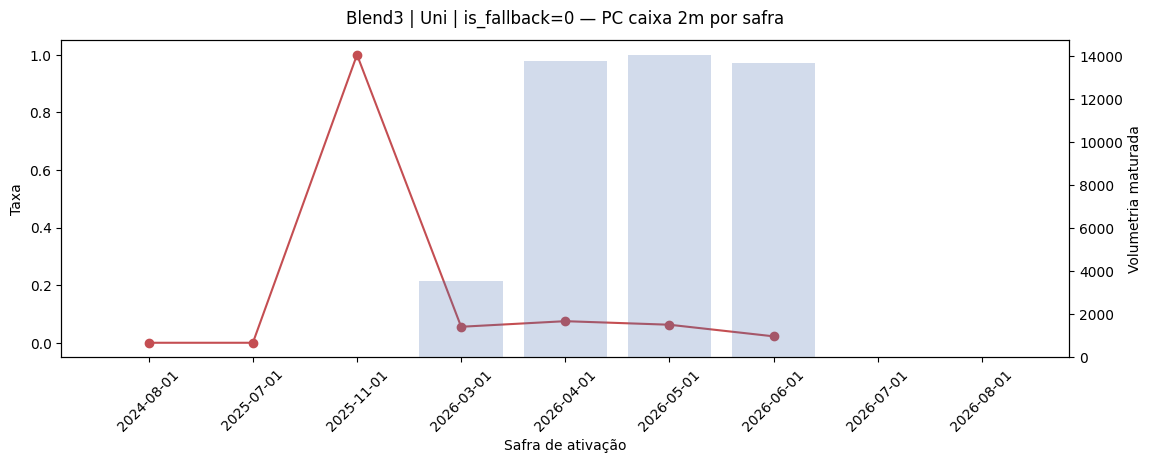

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-08-01 00:00:00,2,2,0,0.00%,100.0%
2025-07-01 00:00:00,1,1,0,0.00%,100.0%
2025-11-01 00:00:00,1,1,1,100.00%,100.0%
2026-03-01 00:00:00,"3,527","3,527",196,5.56%,100.0%
2026-04-01 00:00:00,"13,739","13,739","1,030",7.50%,100.0%
2026-05-01 00:00:00,"14,016","14,016",878,6.26%,100.0%
2026-06-01 00:00:00,"13,646",0,,,0.0%
2026-07-01 00:00:00,"15,108",0,,,0.0%
2026-08-01 00:00:00,"2,697",0,,,0.0%


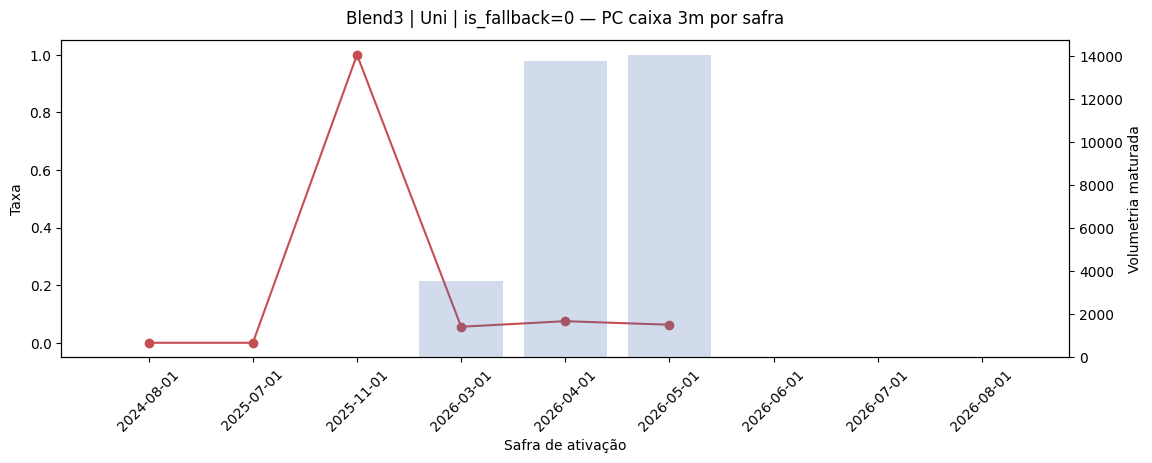

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-08-01 00:00:00,2,2,0,0.00%,100.0%
2025-07-01 00:00:00,1,1,0,0.00%,100.0%
2025-11-01 00:00:00,1,1,1,100.00%,100.0%
2026-03-01 00:00:00,"3,527","3,527",40,1.13%,100.0%
2026-04-01 00:00:00,"13,739","13,739",318,2.31%,100.0%
2026-05-01 00:00:00,"14,016","14,016",137,0.98%,100.0%
2026-06-01 00:00:00,"13,646","13,646",6,0.04%,100.0%
2026-07-01 00:00:00,"15,108",0,,,0.0%
2026-08-01 00:00:00,"2,697",0,,,0.0%


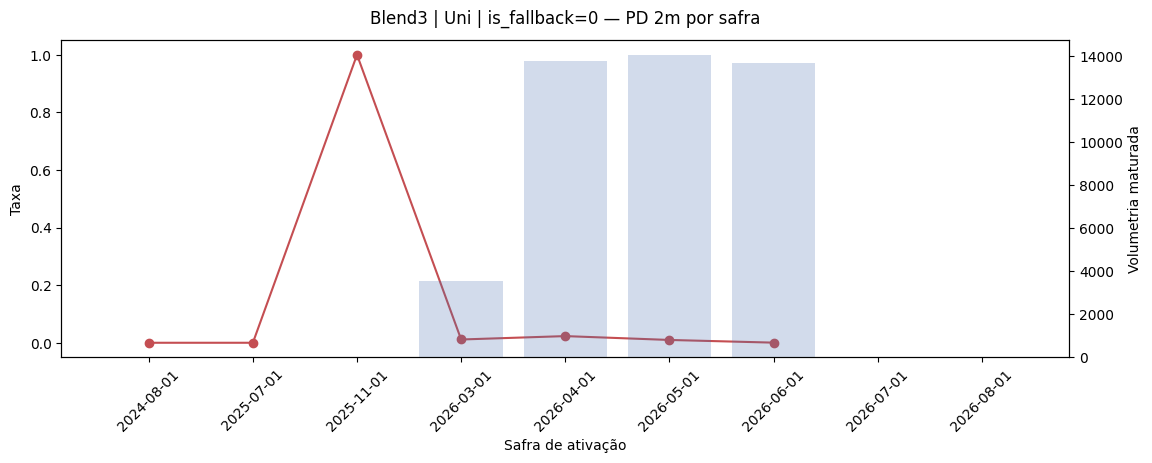

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2024-08-01 00:00:00,2,2,0,0.00%,100.0%
2025-07-01 00:00:00,1,1,0,0.00%,100.0%
2025-11-01 00:00:00,1,1,1,100.00%,100.0%
2026-03-01 00:00:00,"3,527","3,527",40,1.13%,100.0%
2026-04-01 00:00:00,"13,739","13,739",318,2.31%,100.0%
2026-05-01 00:00:00,"14,016","14,016",137,0.98%,100.0%
2026-06-01 00:00:00,"13,646",0,,,0.0%
2026-07-01 00:00:00,"15,108",0,,,0.0%
2026-08-01 00:00:00,"2,697",0,,,0.0%


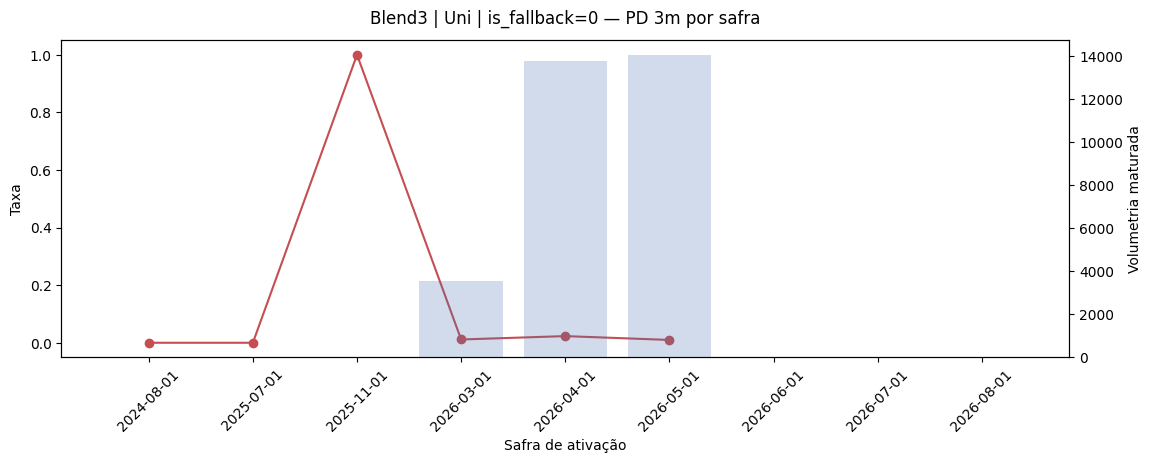

indicador,PC caixa 2m,PC caixa 3m,PC competência 2m,PC competência 3m,PD 2m,PD 3m
faixa_prazo,,,,,,
0,4.88%,6.04%,7.44%,6.33%,1.00%,1.41%
1-2,5.38%,6.80%,8.35%,7.66%,1.16%,1.62%
3-6,5.63%,7.19%,8.91%,9.36%,1.21%,1.76%
7-14,6.51%,8.06%,8.94%,8.68%,1.30%,1.85%
>=15,5.13%,6.53%,5.71%,2.99%,0.86%,1.29%


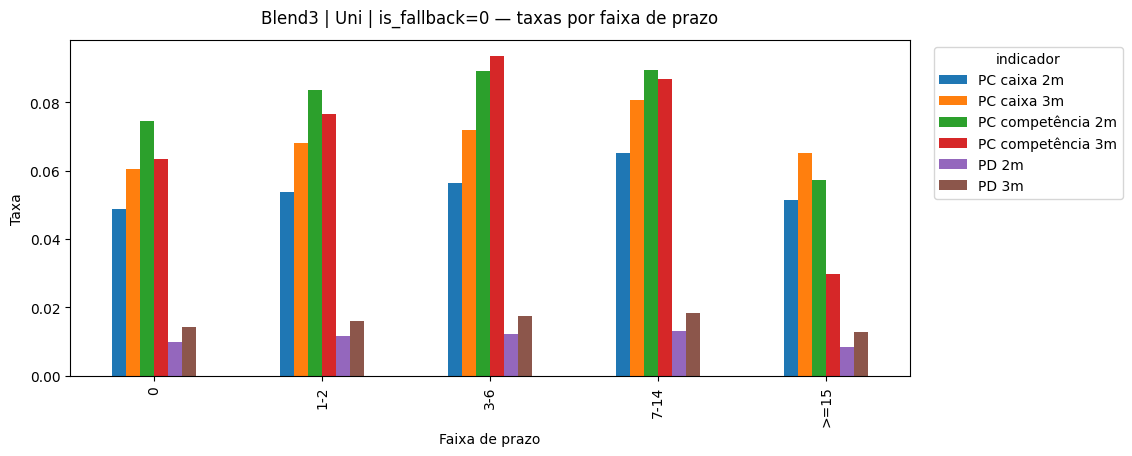

In [211]:
for modelo in BLEND_MODELS_PLOT:
    df_uni_m = df_pf_act[
        (df_pf_act["modelo"] == modelo)
        & (df_pf_act["is_fallback"] == 0)
        & (df_pf_act["is_multiproponente"] == 0)
    ].copy()

    print(f"{modelo} | Uni | is_fallback = 0")
    print(f"Uniproponente: {len(df_uni_m):,}")

    display(
        summarize_targets(df_uni_m).style.format(
            {
                "qtd_ativados": "{:,.0f}",
                "qtd_maturados": "{:,.0f}",
                "cobertura_maturidade": "{:.1%}",
                "taxa": "{:.2%}",
            }
        )
    )

    for target in TARGET_COLS:
        if df_uni_m.empty:
            break
        perf = cohort_perf(df_uni_m, target)
        display(
            perf.style.format(
                {
                    "qtd_ativados": "{:,.0f}",
                    "qtd_maturados": "{:,.0f}",
                    "qtd_maus": "{:,.0f}",
                    "taxa": "{:.2%}",
                    "cobertura_maturidade": "{:.1%}",
                }
            )
        )
        plot_cohort_rates(
            perf,
            title=f"{modelo} | Uni | is_fallback=0 — {TARGET_LABELS[target]} por safra",
        )

    if not df_uni_m.empty:
        uni_by_sla = []
        for target in TARGET_COLS:
            g = df_uni_m.groupby("faixa_prazo", dropna=False)[target]
            uni_by_sla.append(
                pd.DataFrame(
                    {
                        "indicador": TARGET_LABELS[target],
                        "qtd_maturados": g.apply(lambda s: s.notna().sum()),
                        "taxa": g.mean(),
                    }
                ).reset_index()
            )
        uni_sla_rates = pd.concat(uni_by_sla, ignore_index=True)
        pivot_taxa = uni_sla_rates.pivot(index="faixa_prazo", columns="indicador", values="taxa")
        pivot_taxa.index.name = "faixa_prazo"
        pivot_taxa.columns.name = "indicador"
        display(pivot_taxa.style.format("{:.2%}"))
        fig, ax = plt.subplots(figsize=(12, 4.8))
        pivot_taxa.plot(kind="bar", ax=ax)
        ax.set_ylabel("Taxa")
        ax.set_xlabel("Faixa de prazo")
        ax.set_title(f"{modelo} | Uni | is_fallback=0 — taxas por faixa de prazo", pad=12)
        ax.legend(title="indicador", bbox_to_anchor=(1.02, 1), loc="upper left")
        fig.subplots_adjust(left=0.08, right=0.78, top=0.88, bottom=0.18)
        plt.show()


===== Multiproponente (todos) =====
Multiproponente: 22,367


,indicador,qtd_ativados,qtd_maturados,cobertura_maturidade,taxa
0,PC competência 2m,"22,367","20,646",92.3%,4.30%
1,PC competência 3m,"22,367","20,205",90.3%,4.34%
2,PC caixa 2m,"22,367","21,673",96.9%,3.32%
3,PC caixa 3m,"22,367","21,192",94.7%,3.37%
4,PD 2m,"22,367","21,673",96.9%,0.54%
5,PD 3m,"22,367","21,192",94.7%,0.56%


,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,23,3.10%,100.0%
2025-10-01 00:00:00,713,713,30,4.21%,100.0%
2025-11-01 00:00:00,544,544,24,4.41%,100.0%
2025-12-01 00:00:00,460,460,21,4.57%,100.0%
2026-01-01 00:00:00,606,606,22,3.63%,100.0%
2026-02-01 00:00:00,477,477,16,3.35%,100.0%
2026-03-01 00:00:00,513,513,15,2.92%,100.0%
2026-04-01 00:00:00,441,441,11,2.49%,100.0%
2026-05-01 00:00:00,546,0,,,0.0%


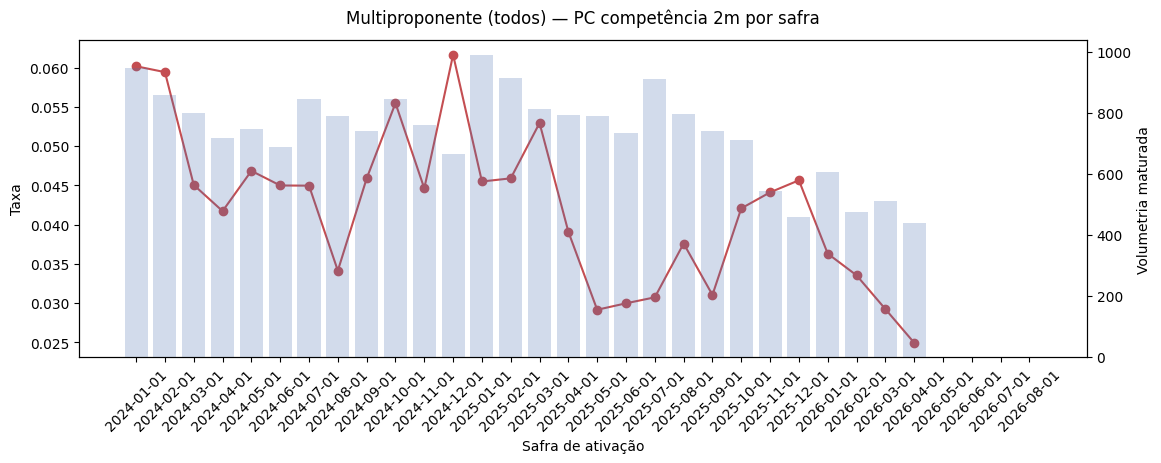

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,23,3.10%,100.0%
2025-10-01 00:00:00,713,713,30,4.21%,100.0%
2025-11-01 00:00:00,544,544,24,4.41%,100.0%
2025-12-01 00:00:00,460,460,21,4.57%,100.0%
2026-01-01 00:00:00,606,606,22,3.63%,100.0%
2026-02-01 00:00:00,477,477,16,3.35%,100.0%
2026-03-01 00:00:00,513,513,15,2.92%,100.0%
2026-04-01 00:00:00,441,0,,,0.0%
2026-05-01 00:00:00,546,0,,,0.0%


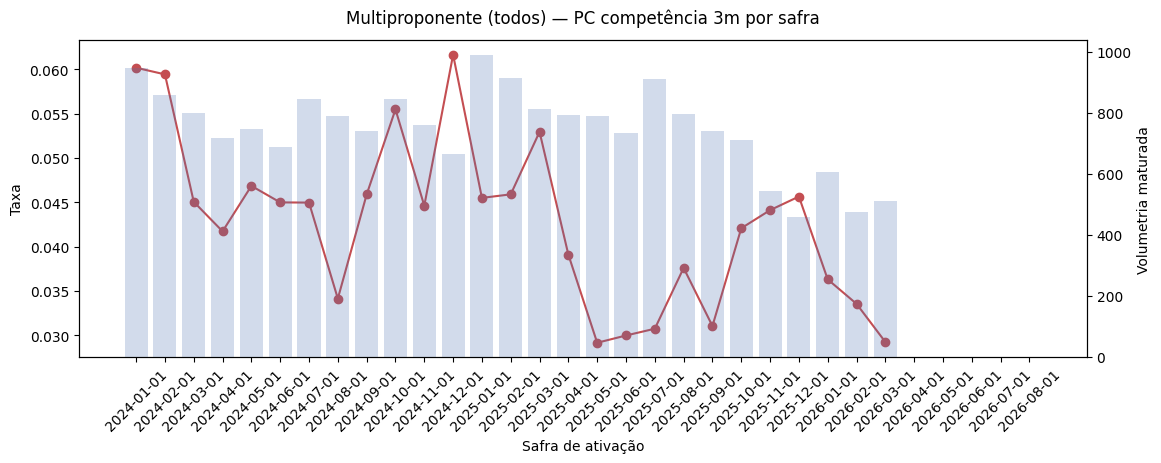

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,18,2.43%,100.0%
2025-10-01 00:00:00,713,713,22,3.09%,100.0%
2025-11-01 00:00:00,544,544,13,2.39%,100.0%
2025-12-01 00:00:00,460,460,13,2.83%,100.0%
2026-01-01 00:00:00,606,606,18,2.97%,100.0%
2026-02-01 00:00:00,477,477,13,2.73%,100.0%
2026-03-01 00:00:00,513,513,13,2.53%,100.0%
2026-04-01 00:00:00,441,441,11,2.49%,100.0%
2026-05-01 00:00:00,546,546,11,2.01%,100.0%


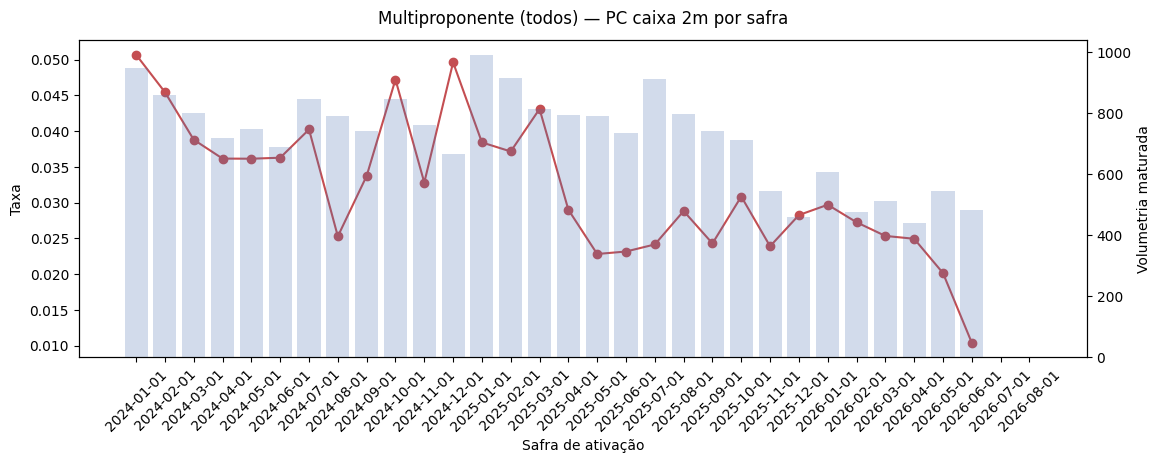

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,18,2.43%,100.0%
2025-10-01 00:00:00,713,713,22,3.09%,100.0%
2025-11-01 00:00:00,544,544,13,2.39%,100.0%
2025-12-01 00:00:00,460,460,13,2.83%,100.0%
2026-01-01 00:00:00,606,606,18,2.97%,100.0%
2026-02-01 00:00:00,477,477,13,2.73%,100.0%
2026-03-01 00:00:00,513,513,13,2.53%,100.0%
2026-04-01 00:00:00,441,441,11,2.49%,100.0%
2026-05-01 00:00:00,546,546,11,2.01%,100.0%


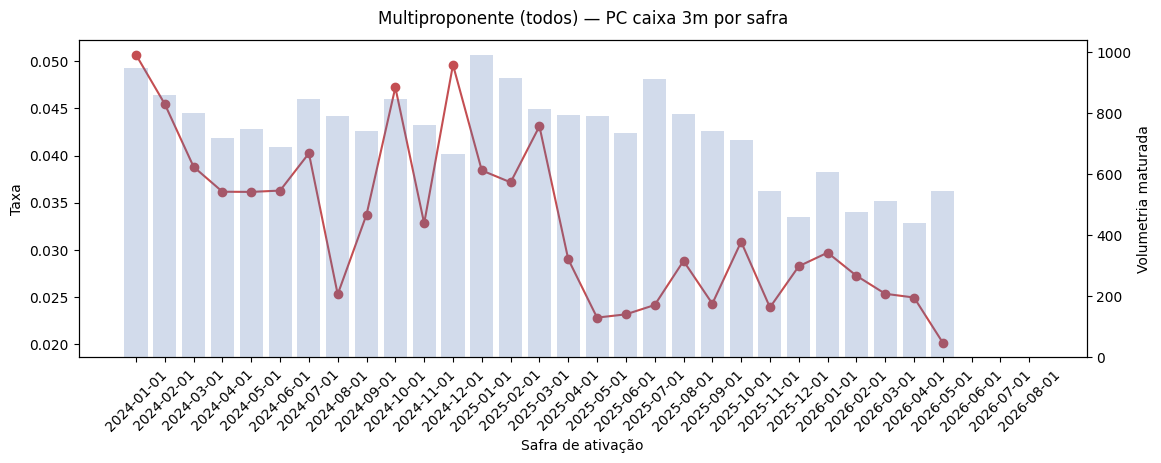

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,3,0.40%,100.0%
2025-10-01 00:00:00,713,713,2,0.28%,100.0%
2025-11-01 00:00:00,544,544,3,0.55%,100.0%
2025-12-01 00:00:00,460,460,4,0.87%,100.0%
2026-01-01 00:00:00,606,606,2,0.33%,100.0%
2026-02-01 00:00:00,477,477,4,0.84%,100.0%
2026-03-01 00:00:00,513,513,3,0.58%,100.0%
2026-04-01 00:00:00,441,441,1,0.23%,100.0%
2026-05-01 00:00:00,546,546,0,0.00%,100.0%


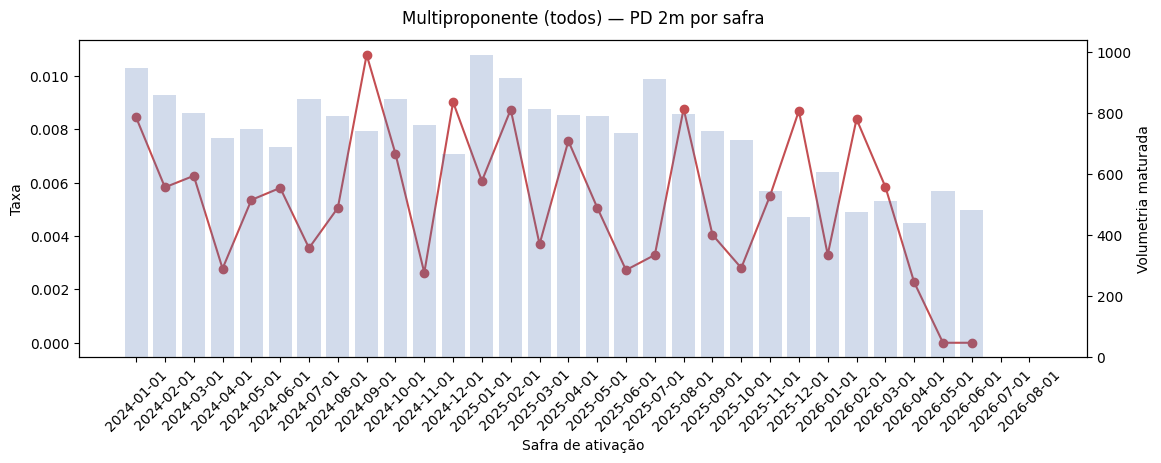

,qtd_ativados,qtd_maturados,qtd_maus,taxa,cobertura_maturidade
safra_ativacao,,,,,
2025-09-01 00:00:00,741,741,3,0.40%,100.0%
2025-10-01 00:00:00,713,713,2,0.28%,100.0%
2025-11-01 00:00:00,544,544,3,0.55%,100.0%
2025-12-01 00:00:00,460,460,4,0.87%,100.0%
2026-01-01 00:00:00,606,606,2,0.33%,100.0%
2026-02-01 00:00:00,477,477,4,0.84%,100.0%
2026-03-01 00:00:00,513,513,3,0.58%,100.0%
2026-04-01 00:00:00,441,441,1,0.23%,100.0%
2026-05-01 00:00:00,546,546,0,0.00%,100.0%


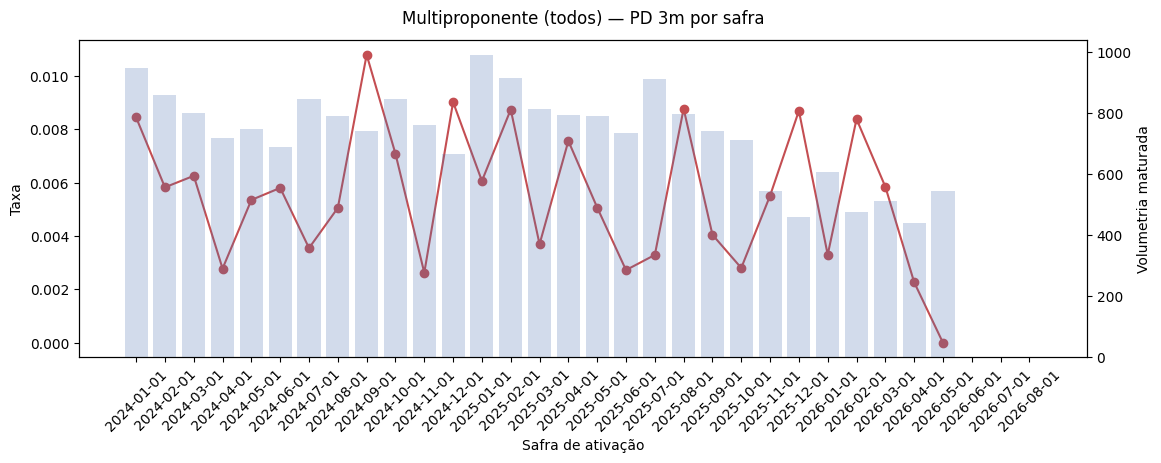

In [212]:
# Multiproponente agregado (sem corte por modelo/fallback)
df_multi_all = df_pf_act[df_pf_act["is_multiproponente"] == 1].copy()
print("===== Multiproponente (todos) =====")
print(f"Multiproponente: {len(df_multi_all):,}")
display(
    summarize_targets(df_multi_all).style.format(
        {
            "qtd_ativados": "{:,.0f}",
            "qtd_maturados": "{:,.0f}",
            "cobertura_maturidade": "{:.1%}",
            "taxa": "{:.2%}",
        }
    )
)

for target in TARGET_COLS:
    if df_multi_all.empty:
        break
    perf = cohort_perf(df_multi_all, target)
    display(
        perf.tail(12).style.format(
            {
                "qtd_ativados": "{:,.0f}",
                "qtd_maturados": "{:,.0f}",
                "qtd_maus": "{:,.0f}",
                "taxa": "{:.2%}",
                "cobertura_maturidade": "{:.1%}",
            }
        )
    )
    plot_cohort_rates(
        perf,
        title=f"Multiproponente (todos) — {TARGET_LABELS[target]} por safra",
    )

In [213]:
# Fallback = 1 nao e plotado (mantido comentado caso precise no futuro)
# for modelo in BLEND_MODELS_PLOT:
#     df_fb = df_pf_act[
#         (df_pf_act["modelo"] == modelo)
#         & (df_pf_act["is_fallback"] == 1)
#         & (df_pf_act["is_multiproponente"] == 0)
#     ].copy()
#     print(f"===== {modelo} | Uni | is_fallback = 1 =====")
#     display(summarize_targets(df_fb))
#     for target in TARGET_COLS:
#         if df_fb.empty:
#             break
#         plot_cohort_rates(
#             cohort_perf(df_fb, target),
#             title=f"{modelo} | Uni | is_fallback=1 — {TARGET_LABELS[target]} por safra",
#         )
